In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc

In [2]:
dados = pd.read_csv("/workspaces/CEA-1/dados_filtrados.csv")
linhas, colunas = dados.shape
print("Dados:", linhas, "linhas e", colunas, "colunas")

Dados: 1030 linhas e 65 colunas


---
# **Visualização dos valores**
---

In [3]:
print("Colunas em dados:")
print("""
""")
for i, coluna in enumerate(dados.columns, start=1):
    print(f"{i:02d}. {coluna}")
print(f"\nTotal de colunas: {len(dados.columns)}")

Colunas em dados:


01. cls_fin_ajustada
02. dt_not_ano
03. regiao
04. pais_nasc
05. sexo
06. cor
07. gestante
08. cod_prod_ajustada
09. dt_apl_ano
10. dose_ajustada
11. via_adm_ajustada
12. local_aplic_ajustada
13. tp_med
14. cls_ei_ajustada
15. tp_atd_ajustada
16. cls_eien
17. idade_anos
18. evol_num
19. cls_compl_ajustada
20. dor_abdominal
21. dor_no_corpo
22. artralgia
23. cefaleia
24. dor
25. exantema_local
26. exantema
27. edema
28. eritema
29. calor
30. enduracao
31. abscesso_quente
32. lesao
33. linfonodomegalia
34. prurido
35. febre
36. nausea
37. emese
38. diarreia
39. tontura
40. sincope
41. parestesia
42. convulsao
43. confusao_mental
44. fraqueza
45. hipotensao
46. taquicardia
47. bradicardia
48. extremidades_frias
49. palidez
50. sudorese
51. urticaria
52. broncoespasmo
53. dispneia
54. angioedema
55. tremor
56. fotofobia
57. visao_turva
58. guillain_barre
59. encefalite
60. epilepsia
61. paralisia
62. purpura_trombocitopenica
63. manifestacoes_locais
64. manifestacoes_si

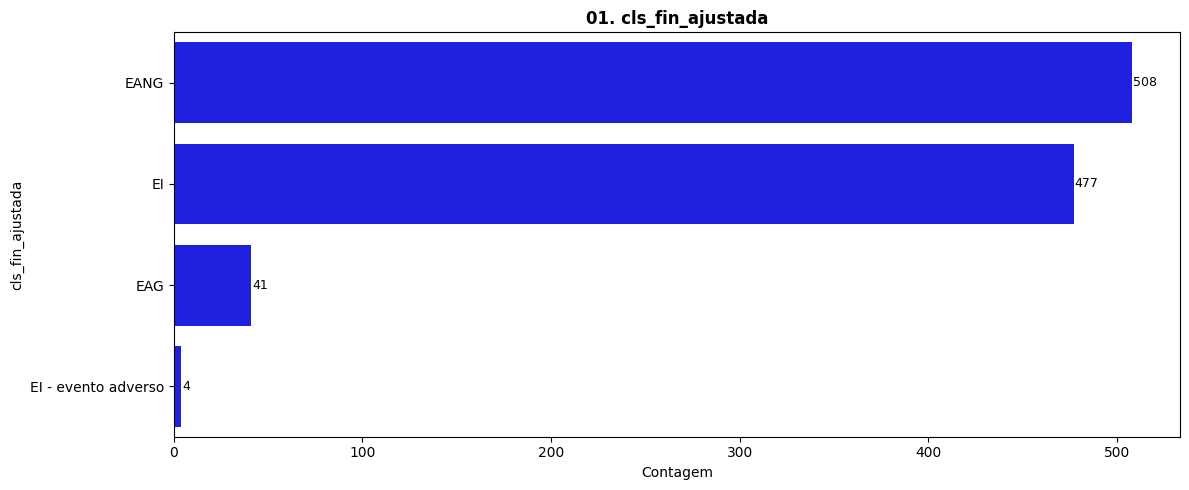

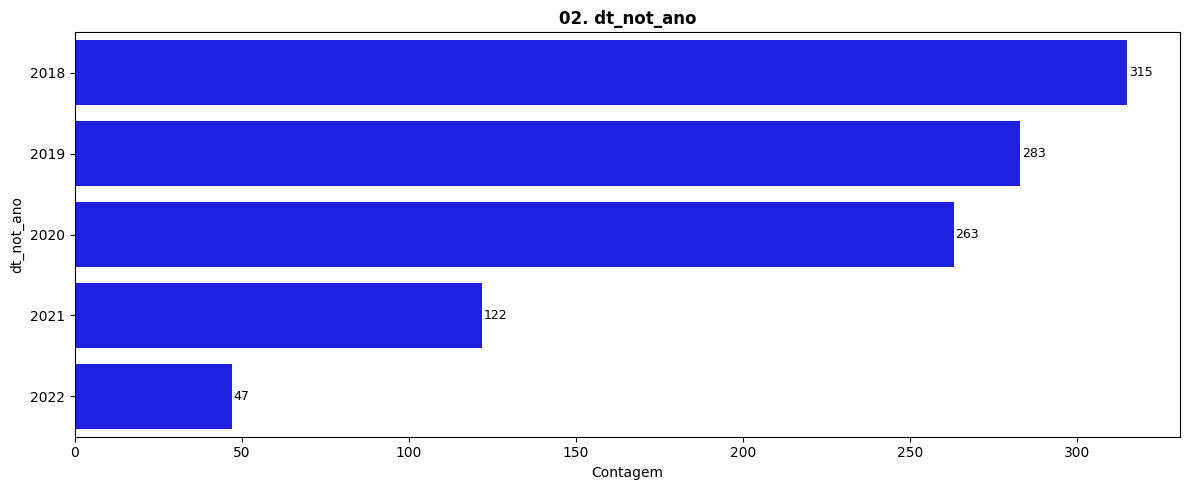

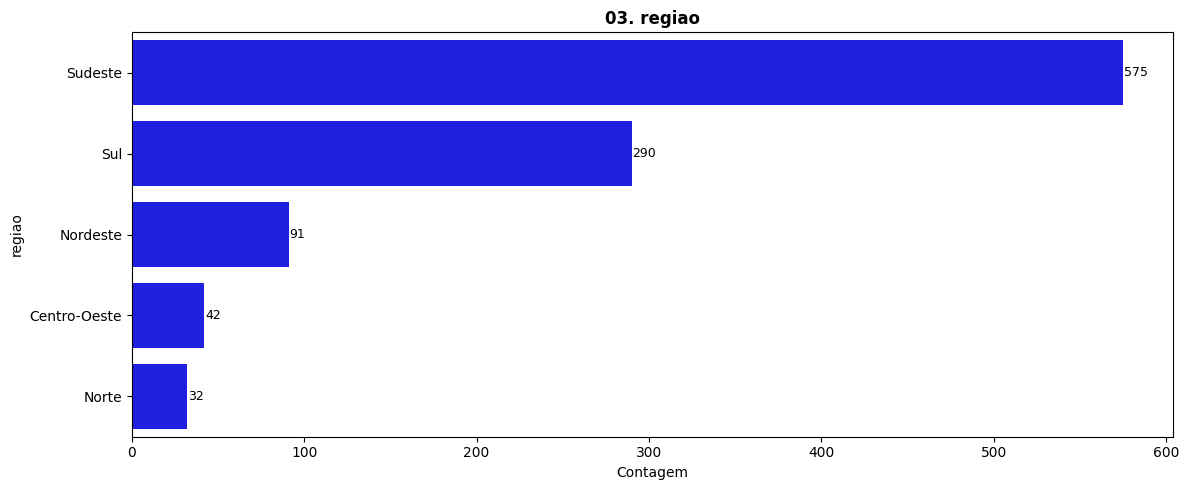

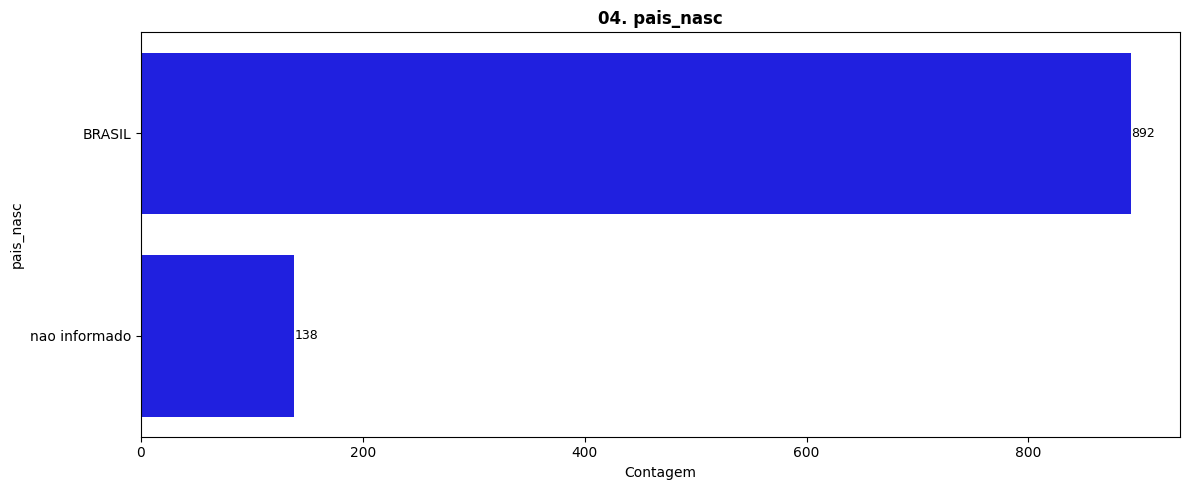

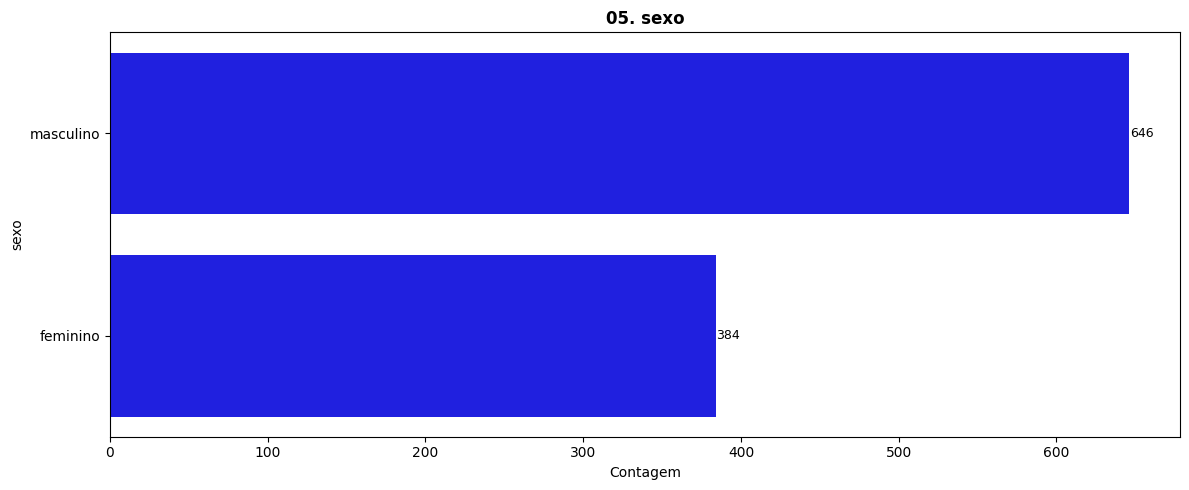

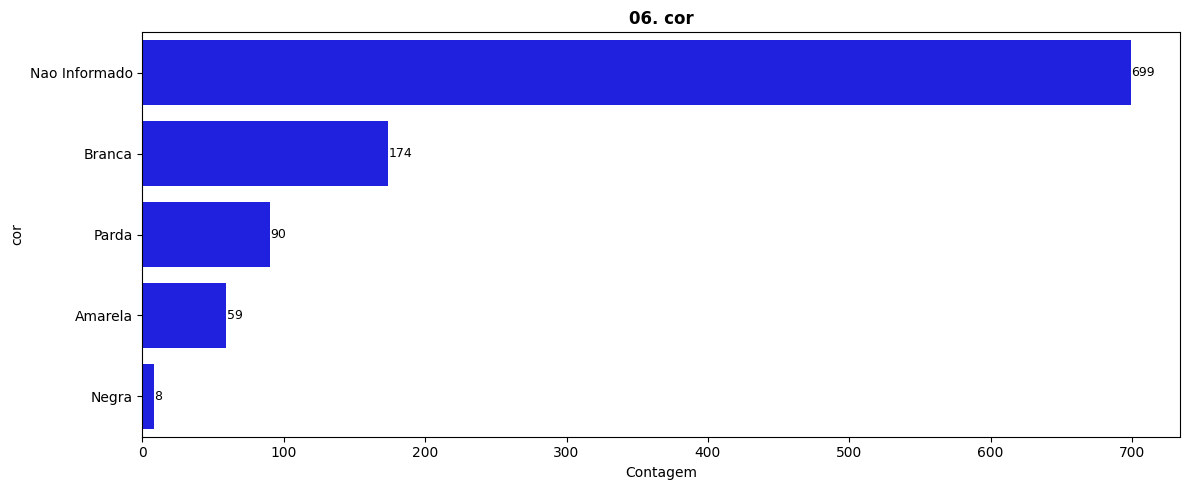

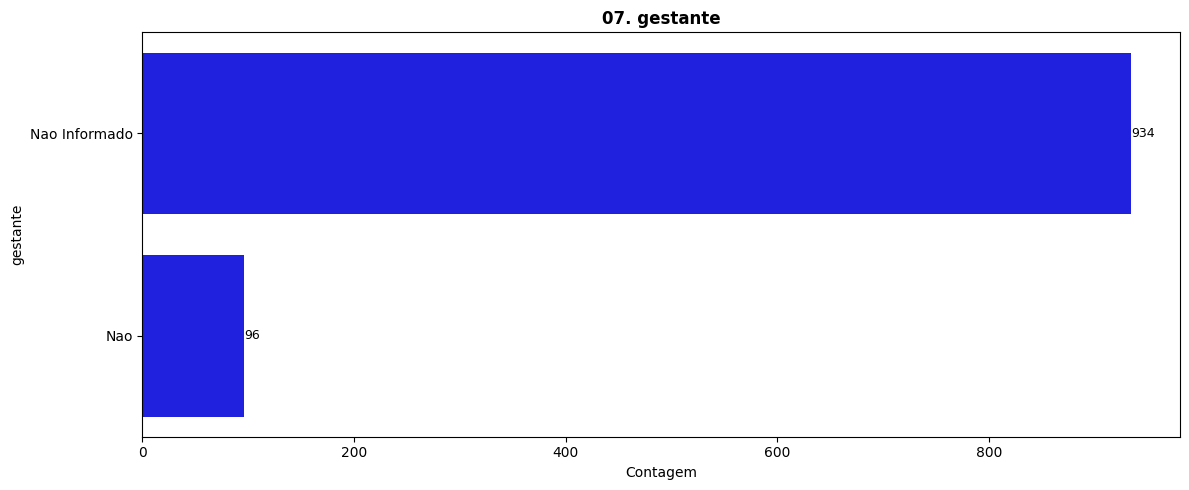

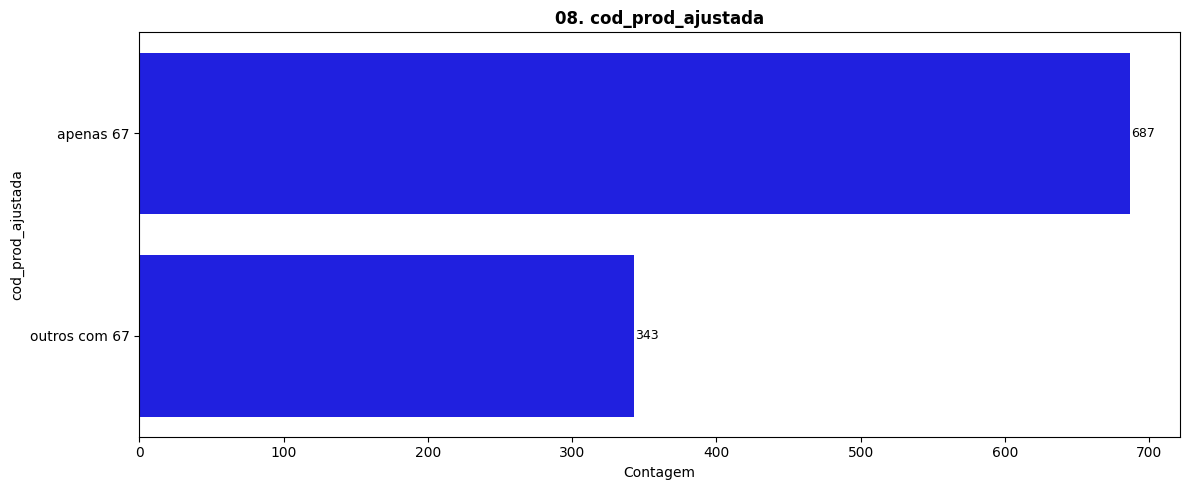

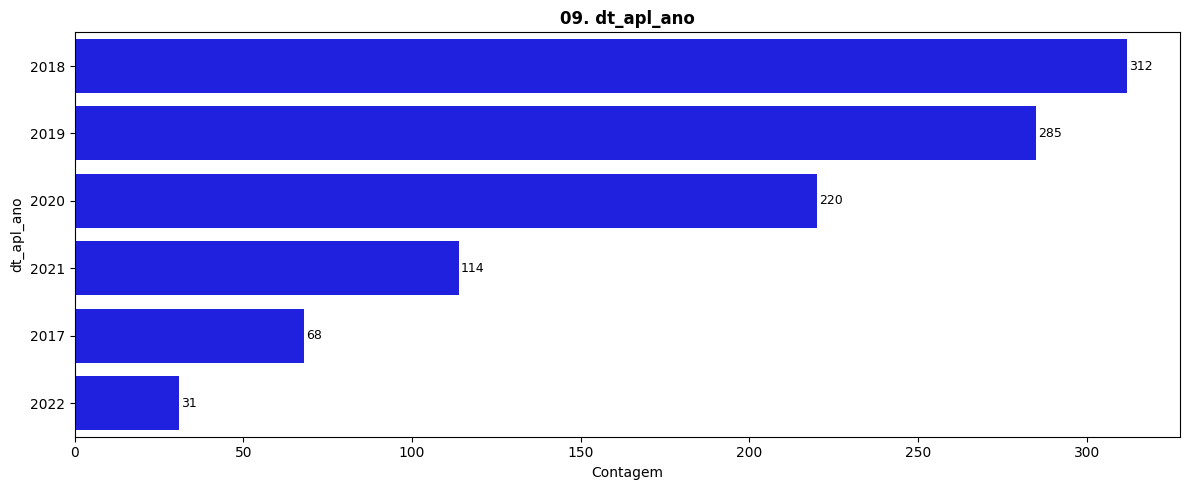

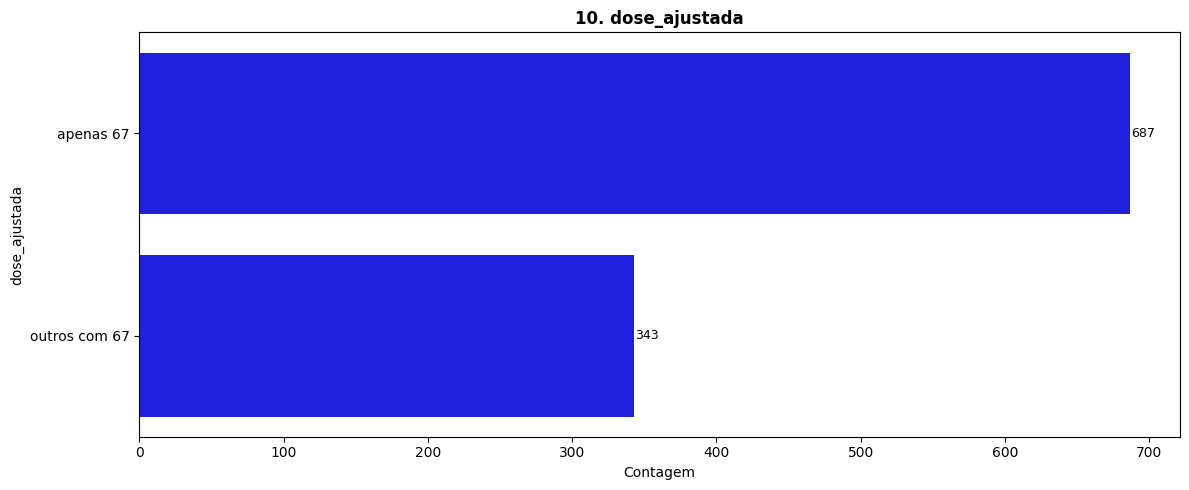

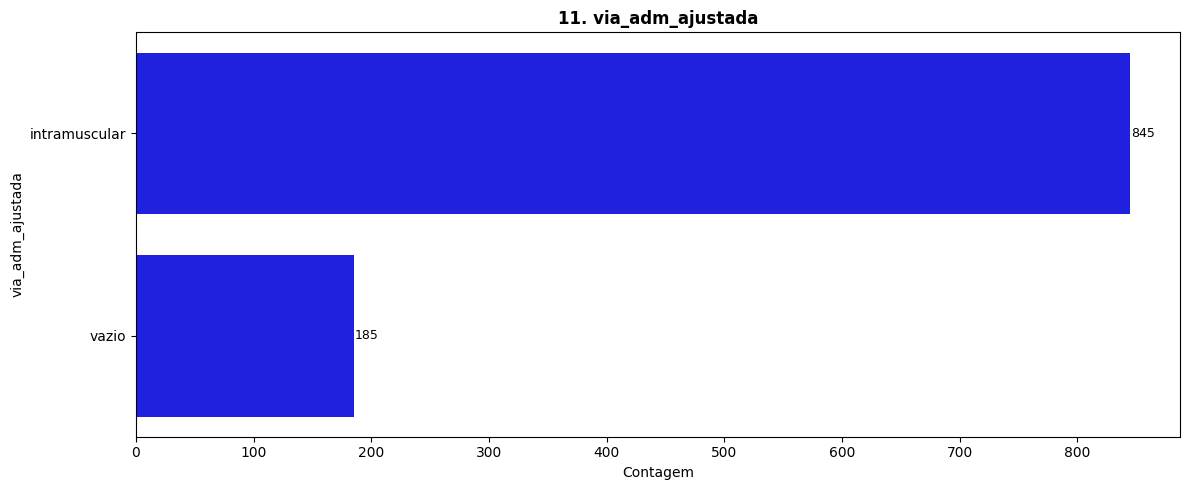

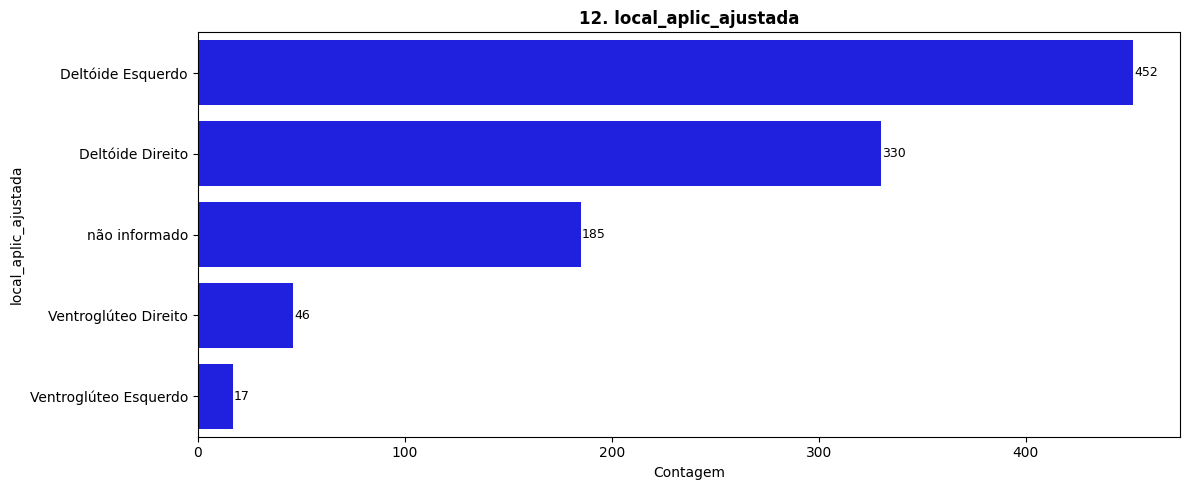

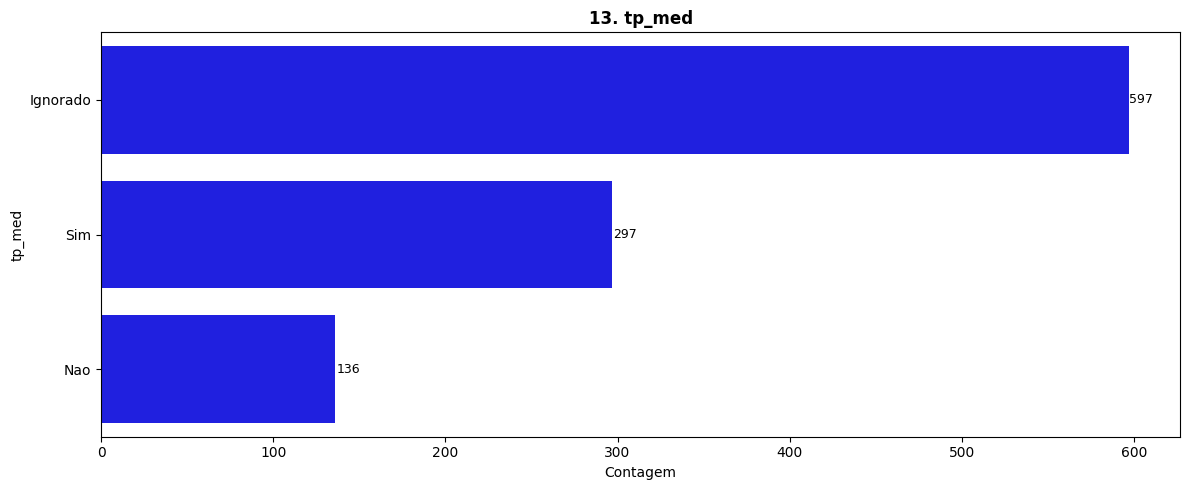

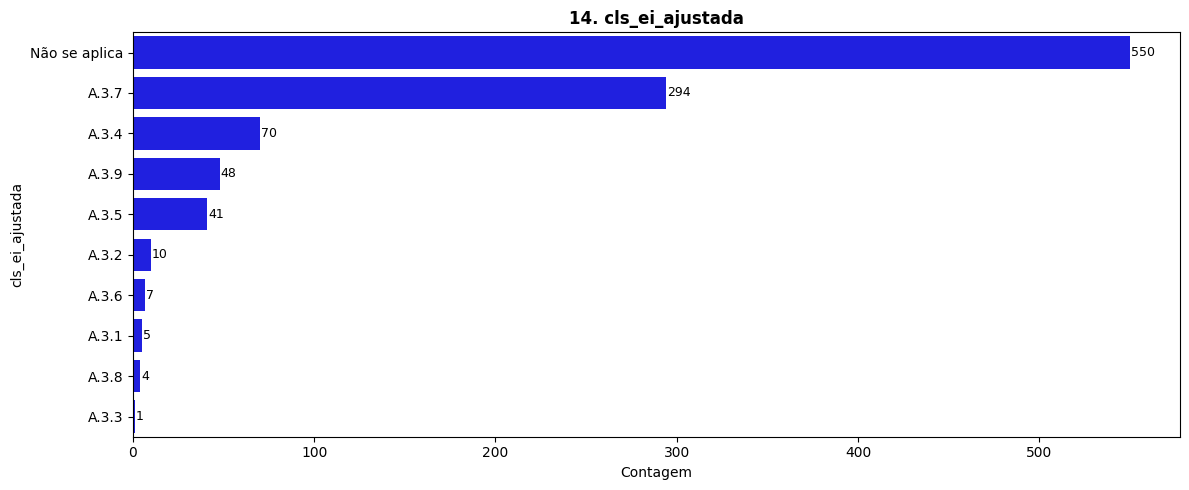

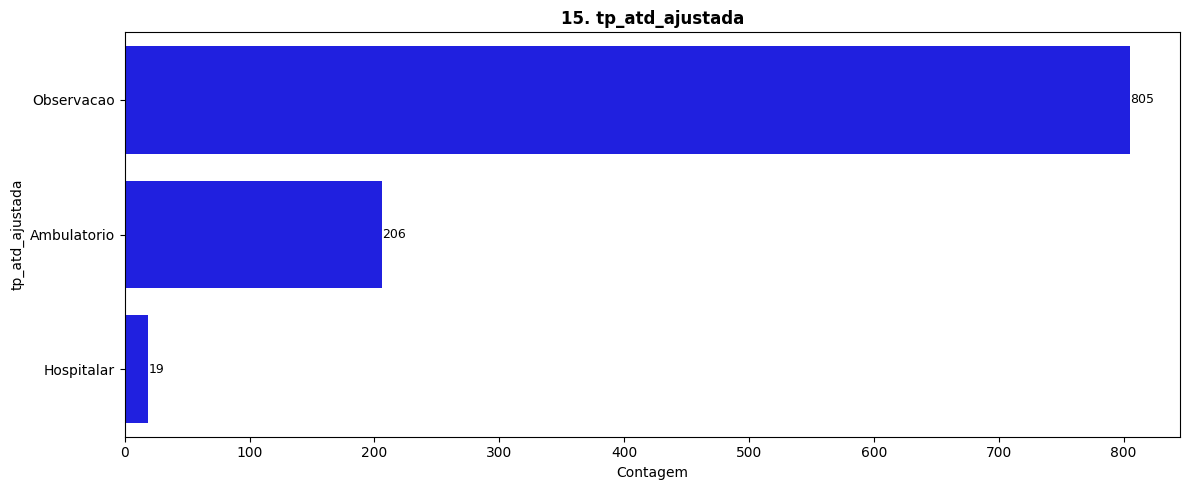

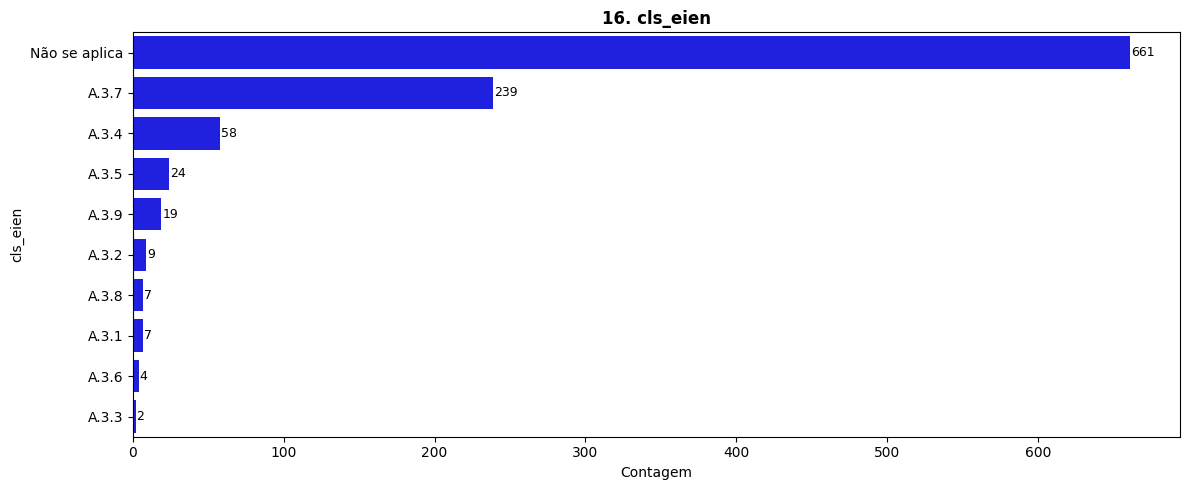

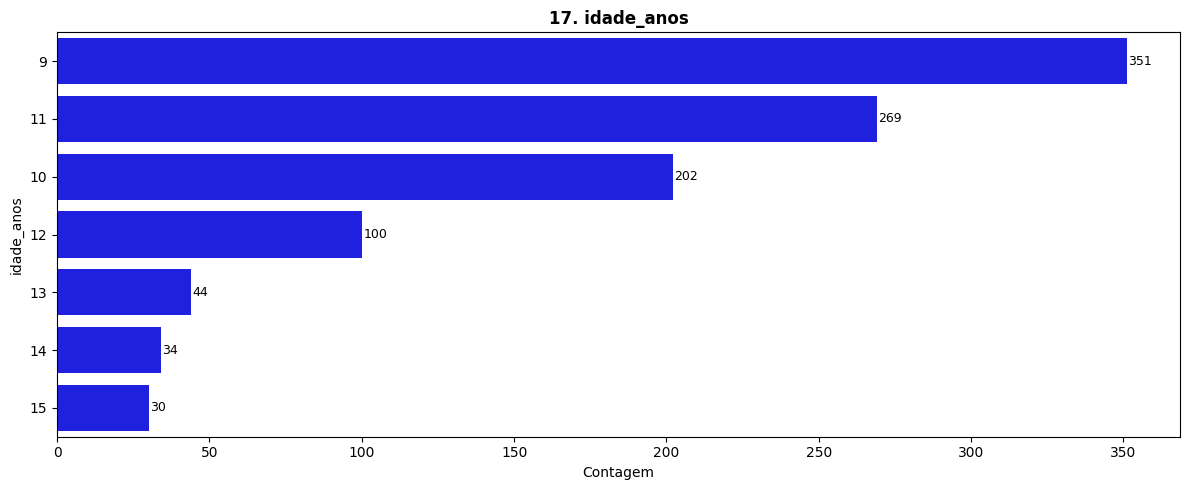

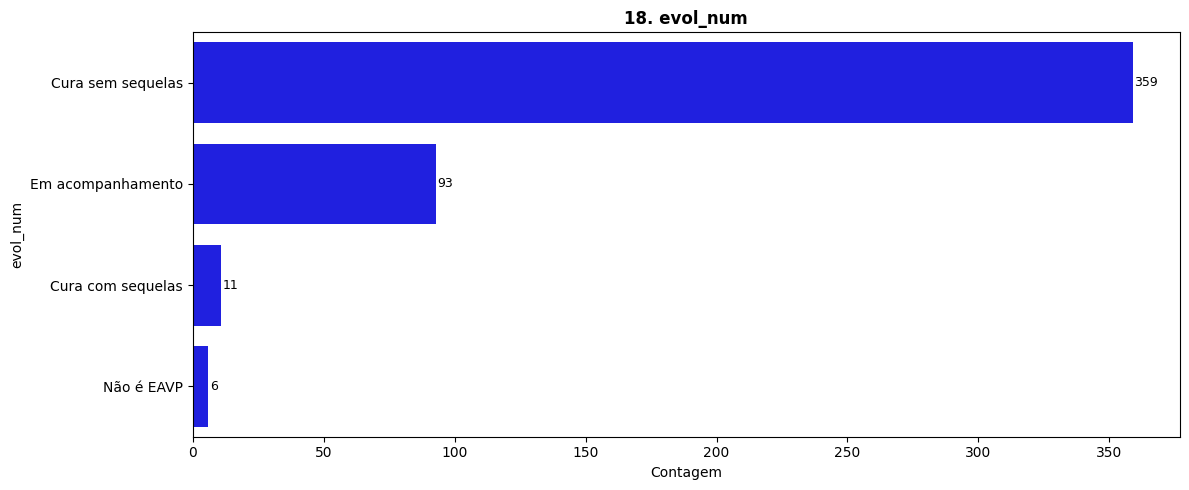

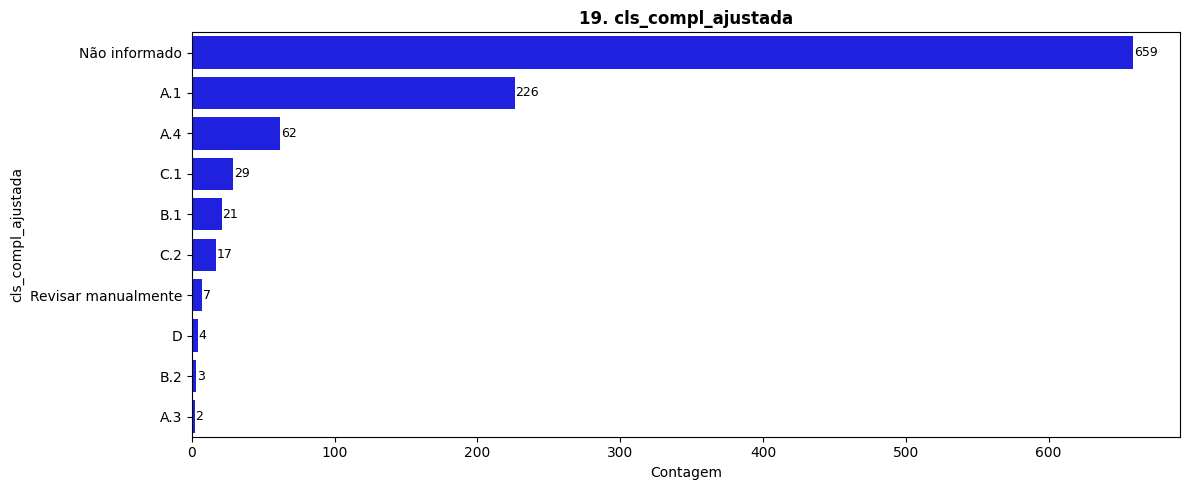

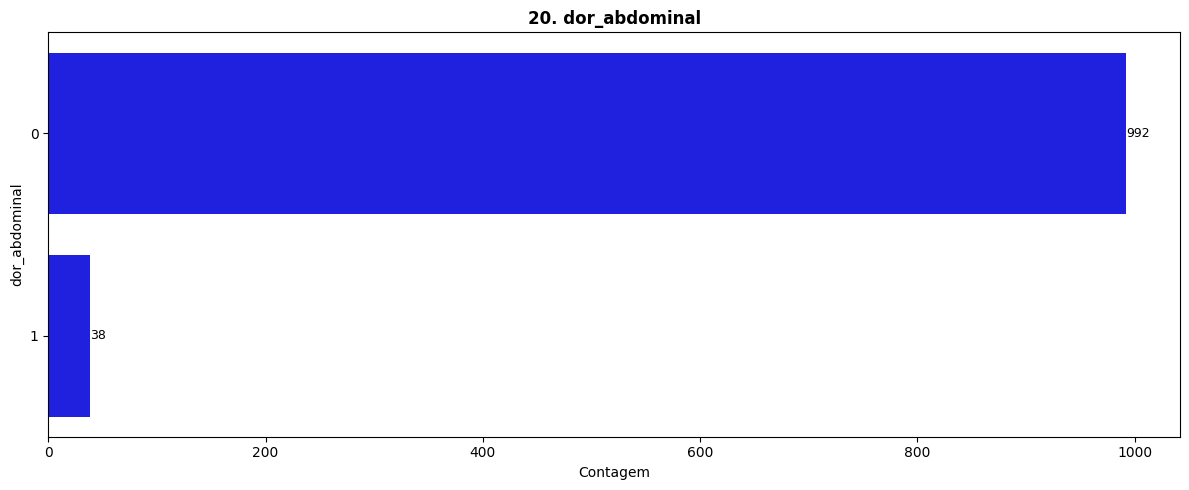

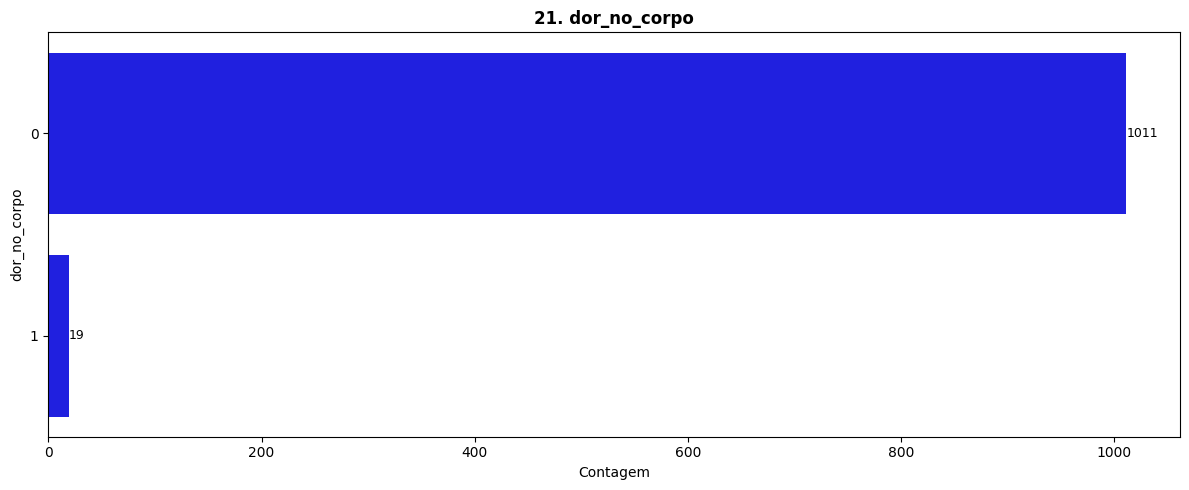

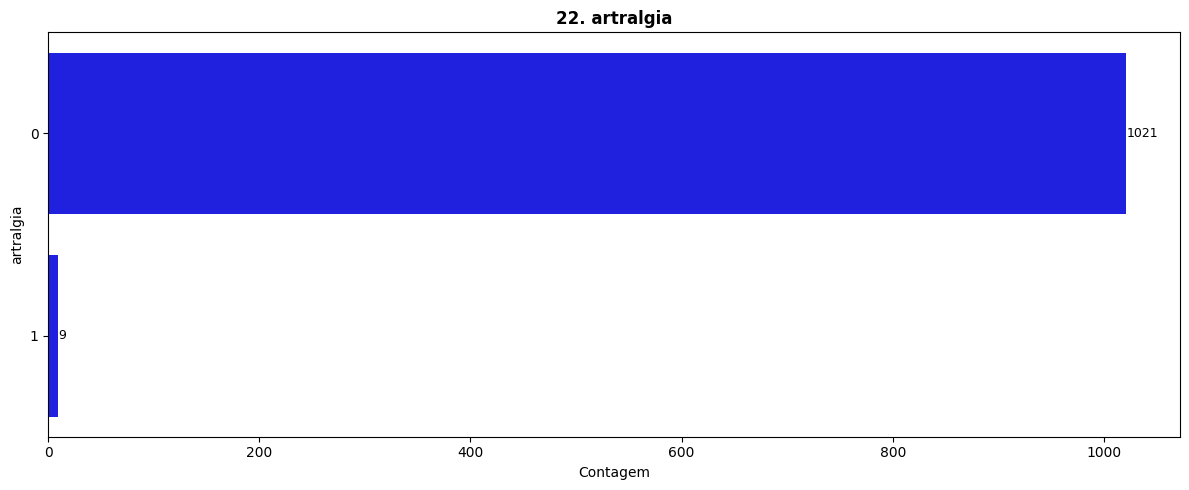

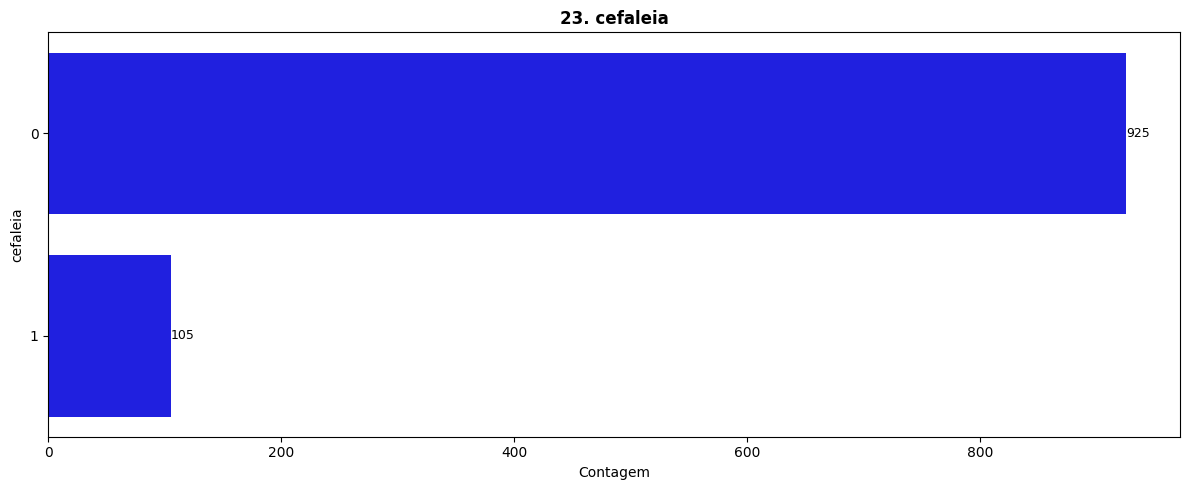

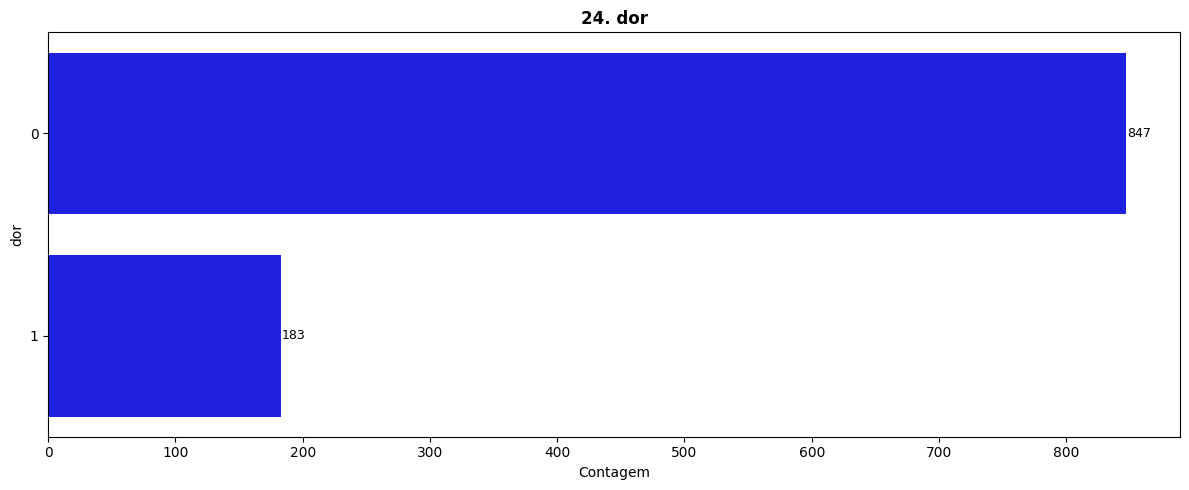

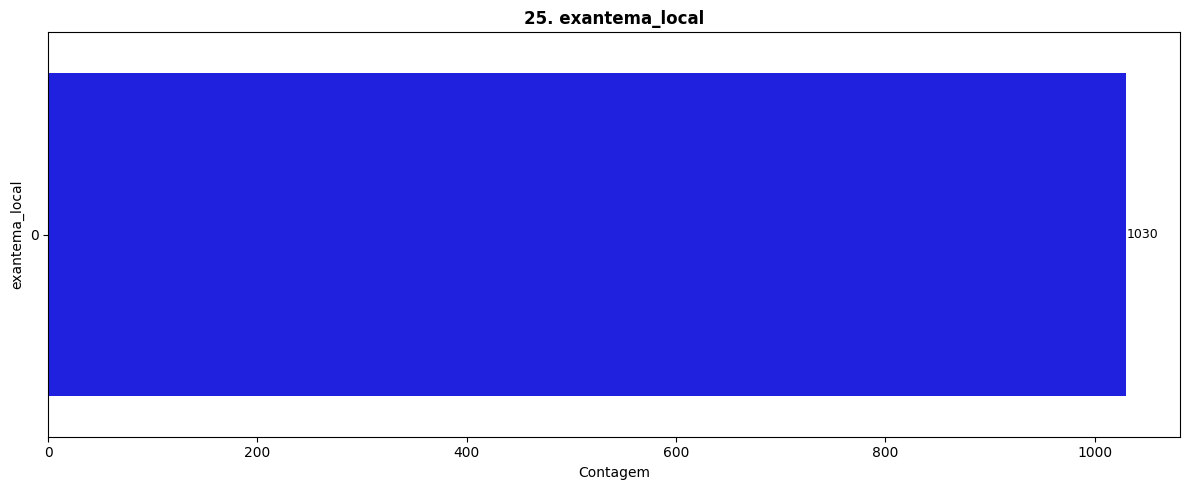

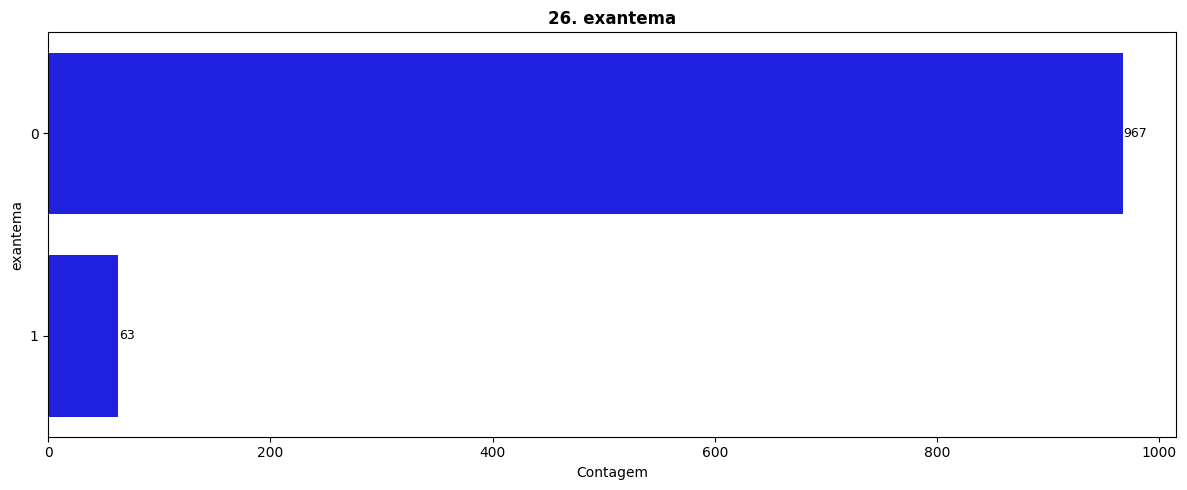

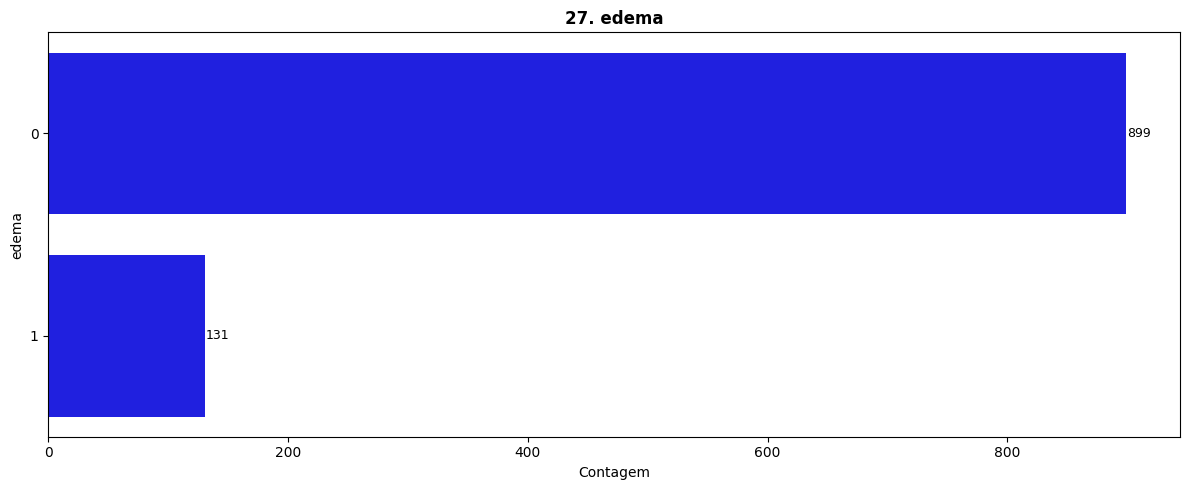

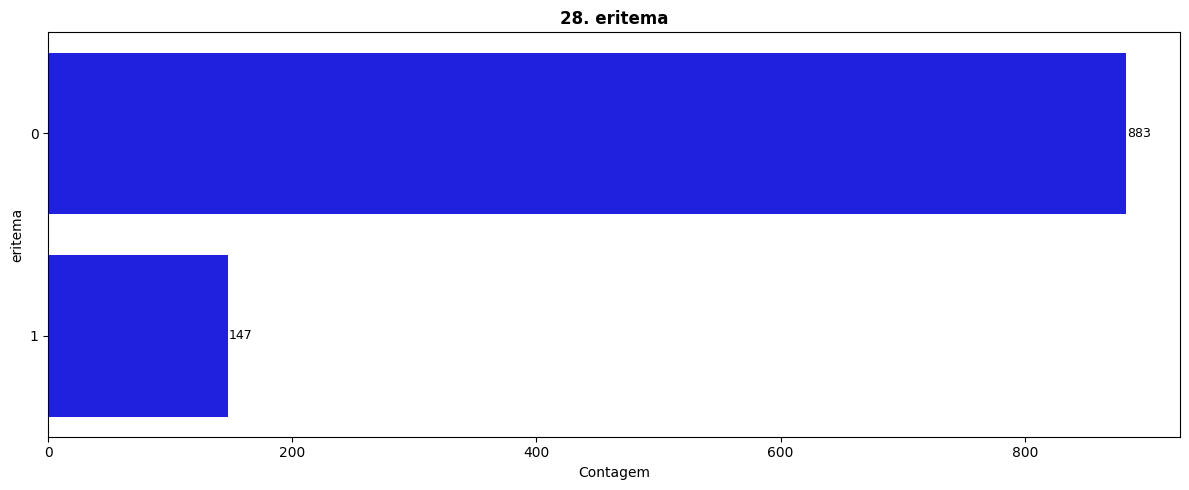

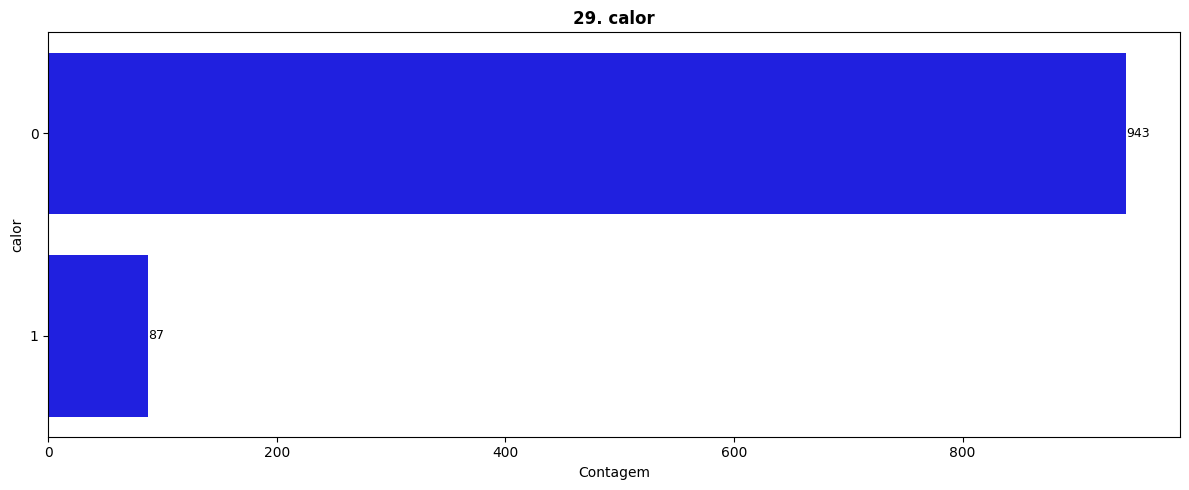

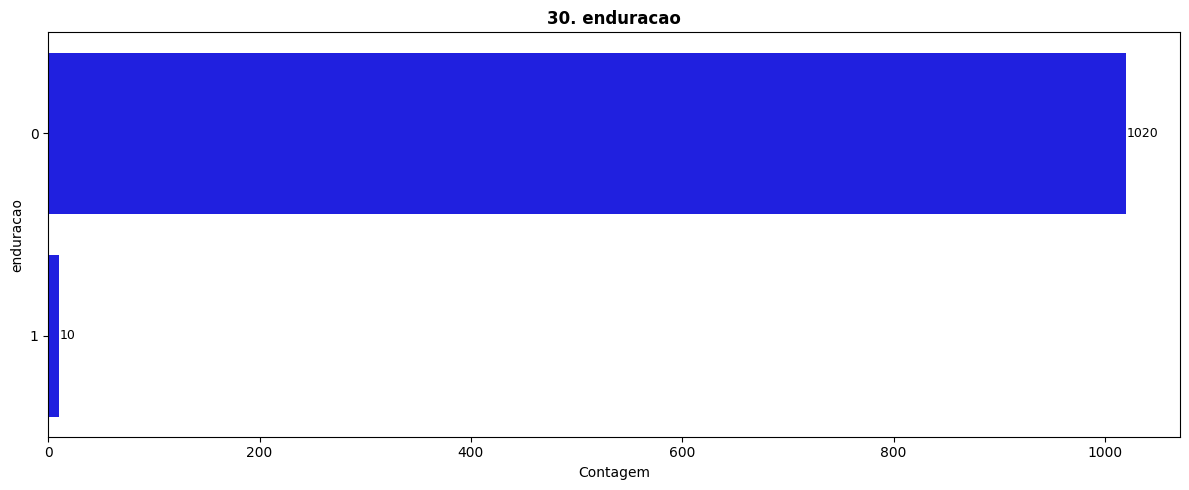

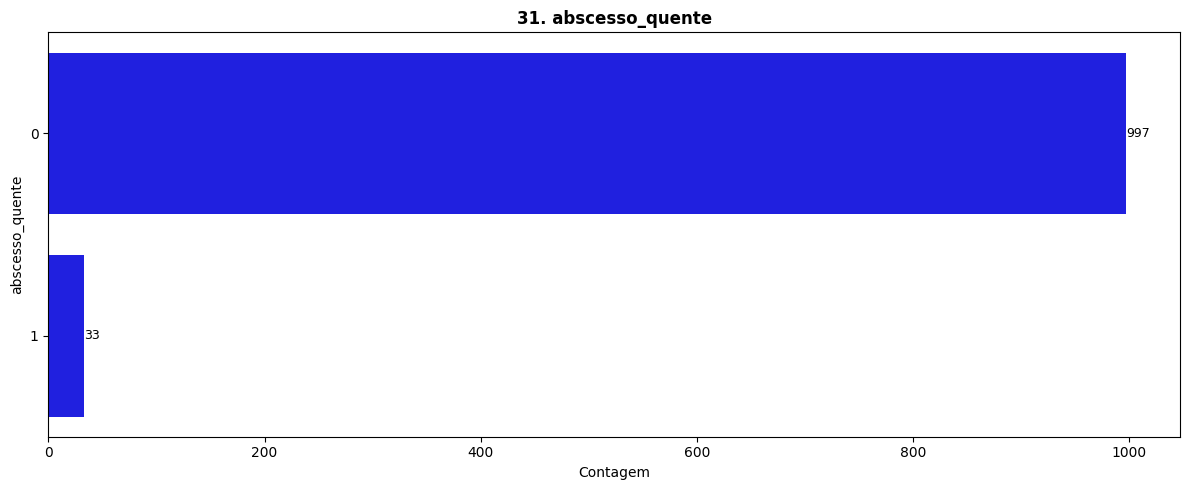

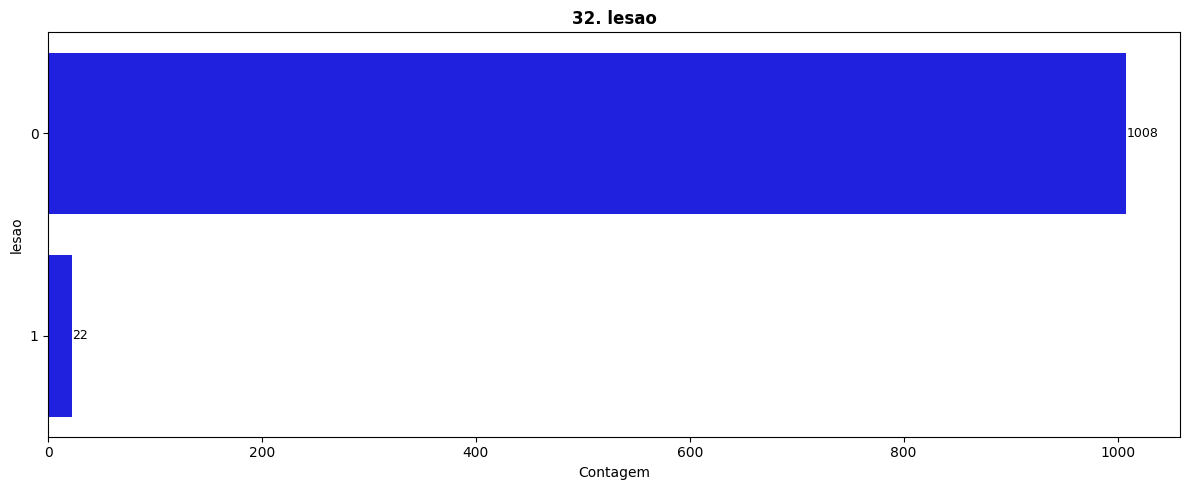

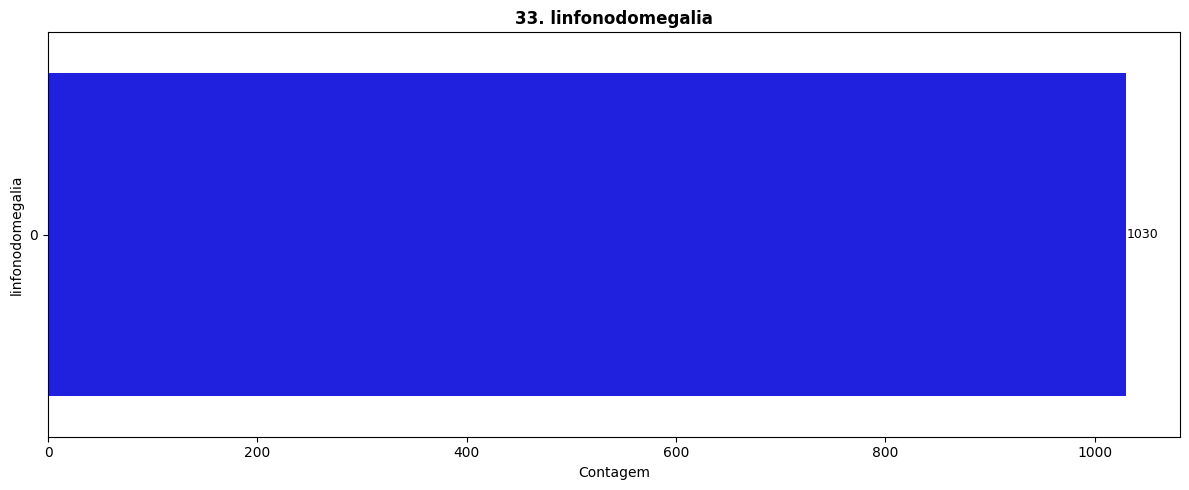

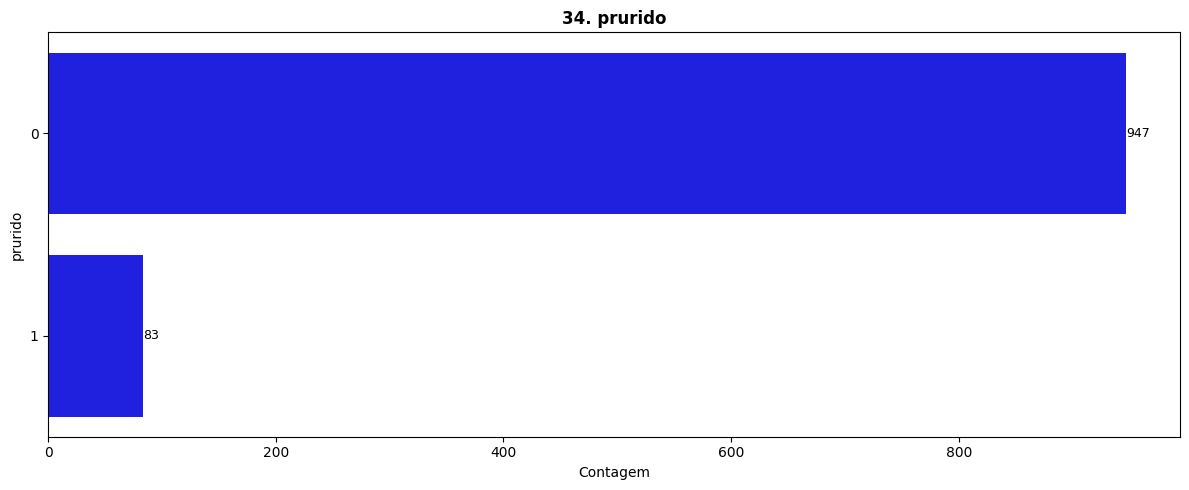

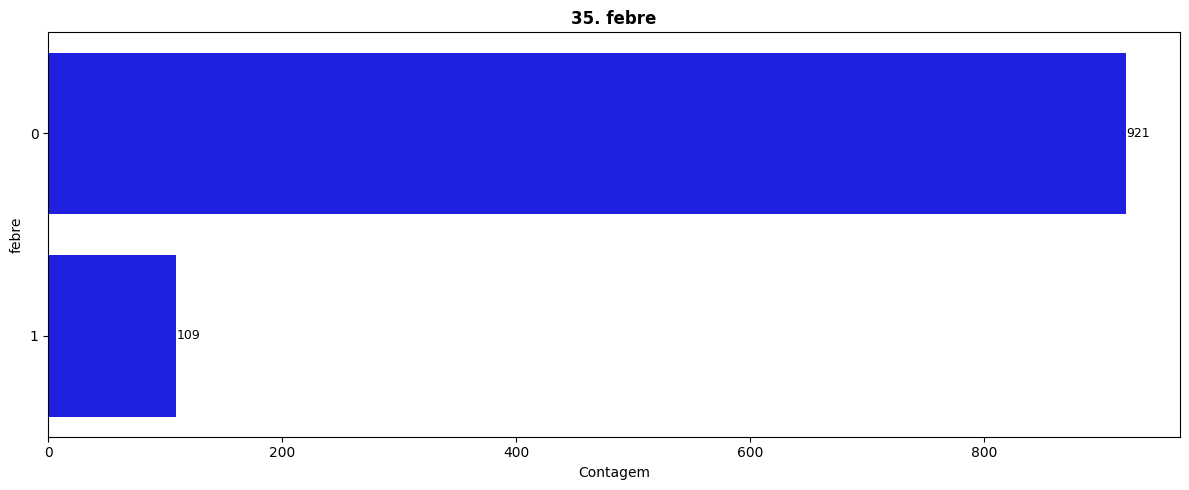

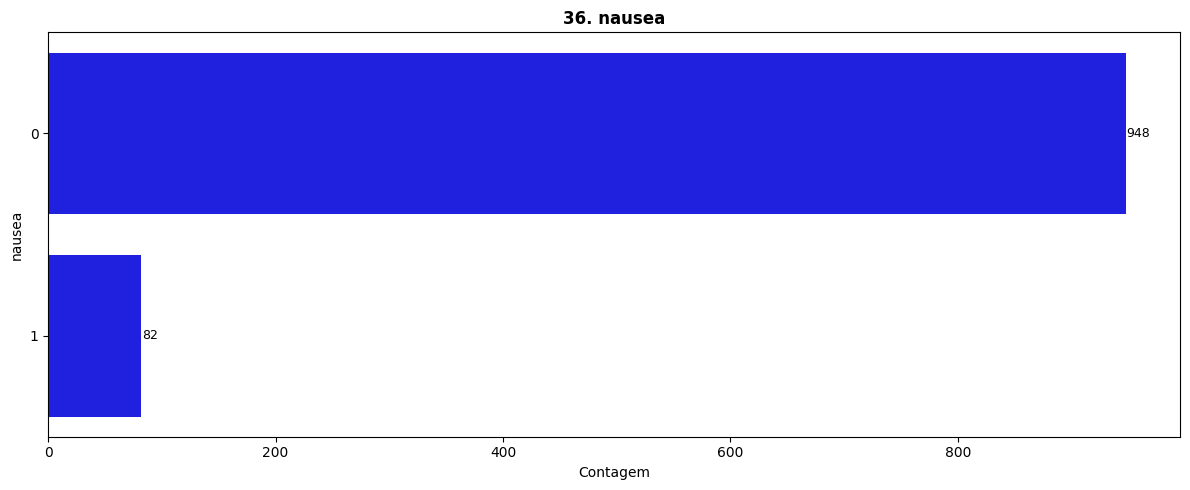

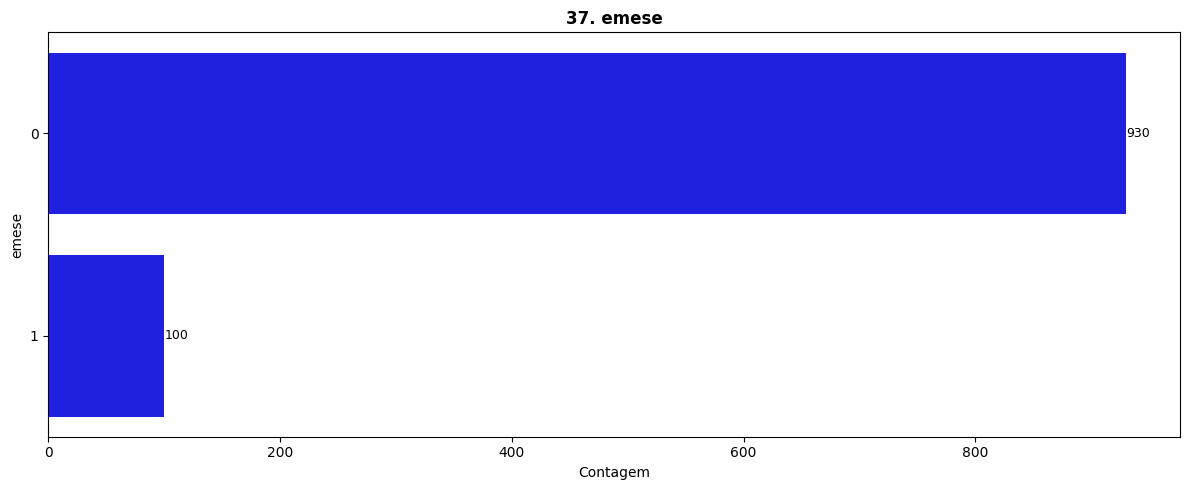

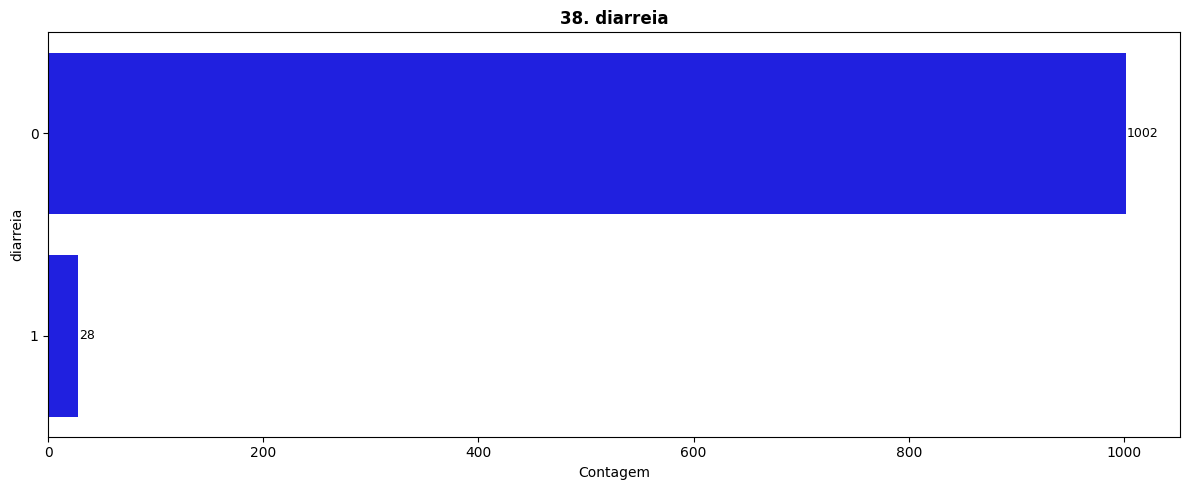

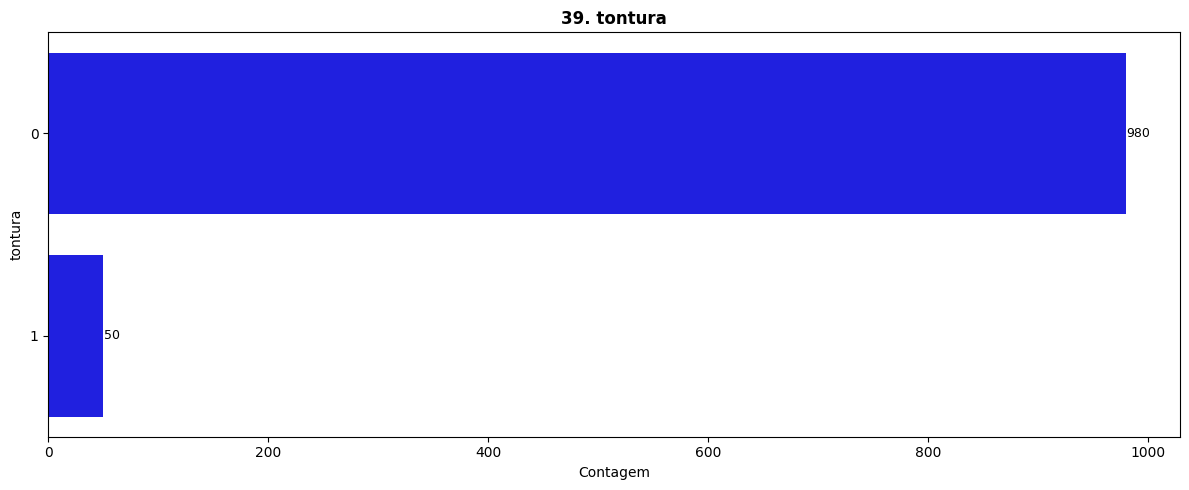

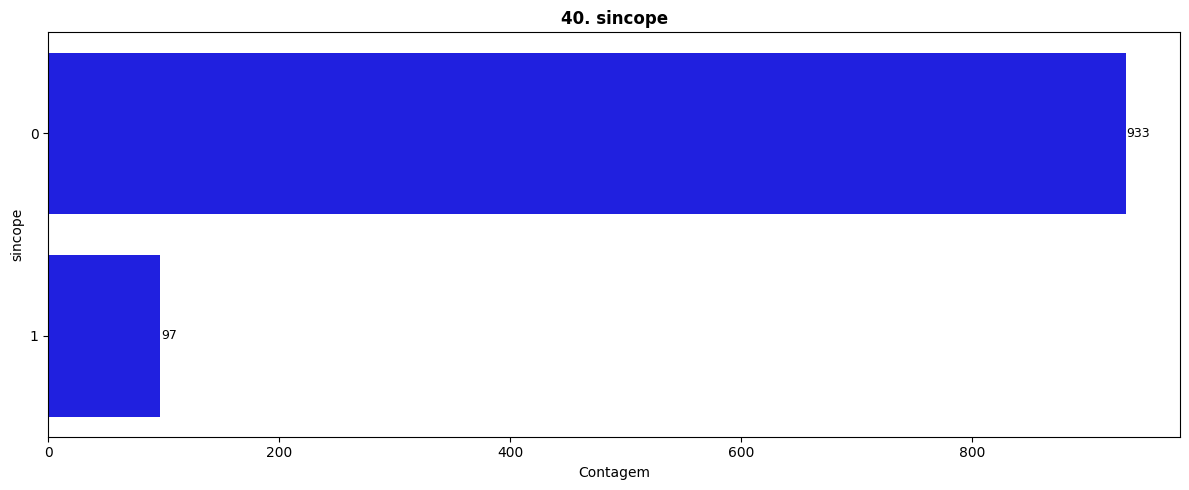

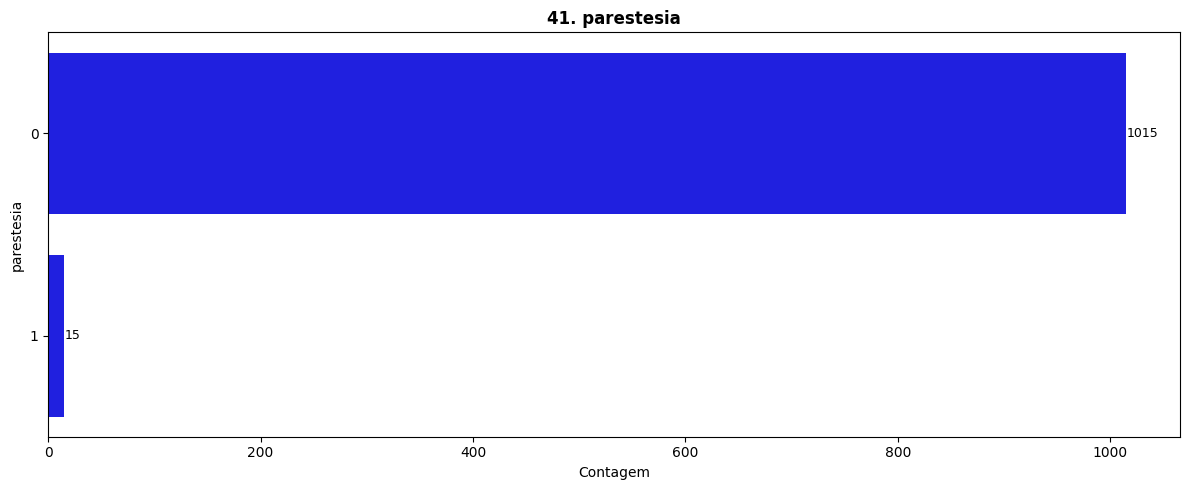

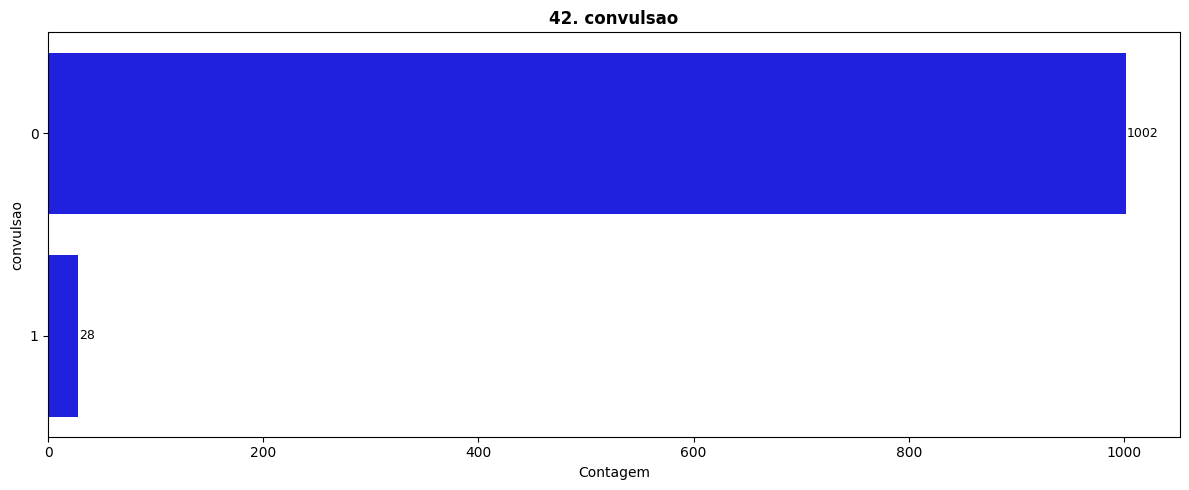

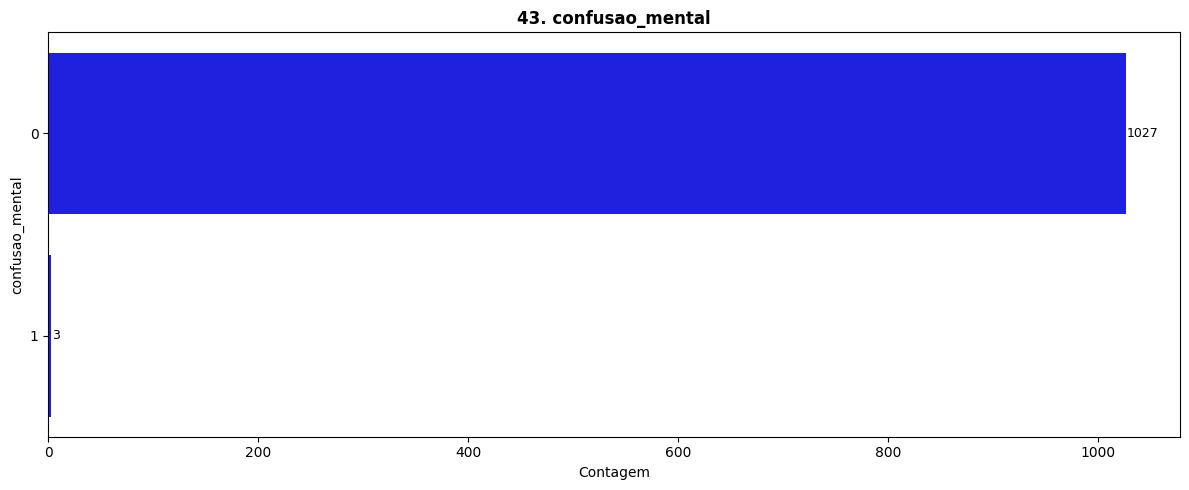

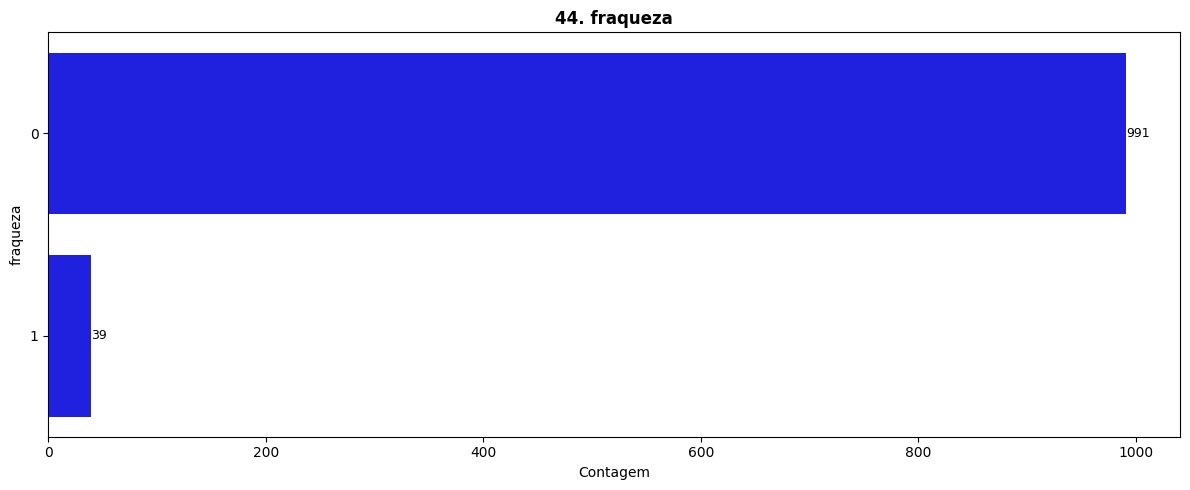

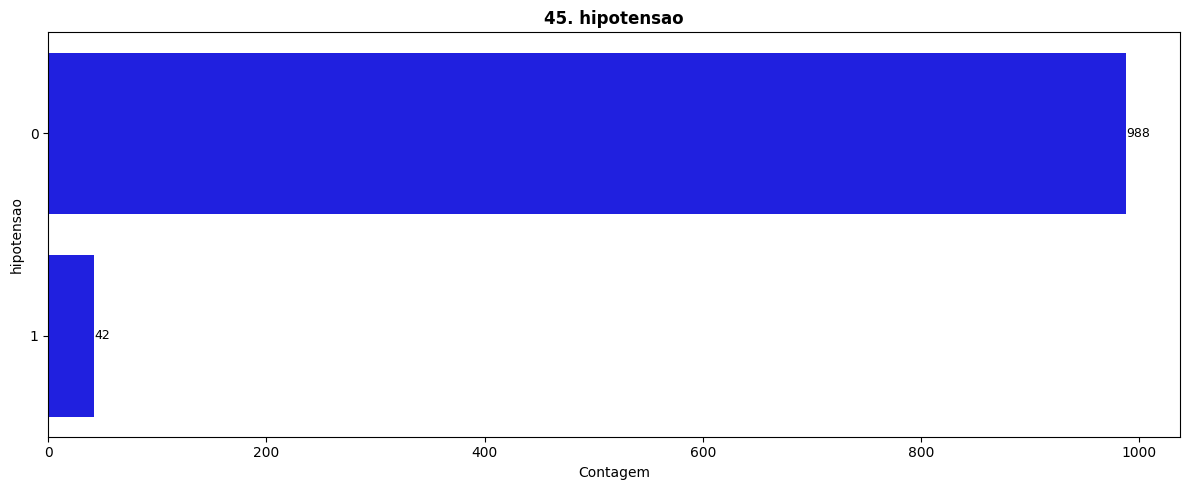

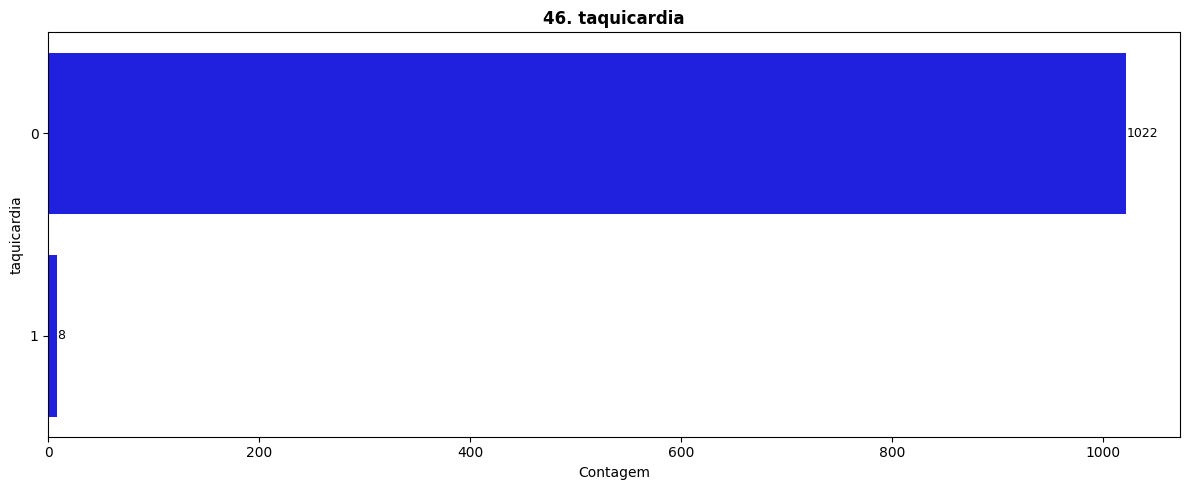

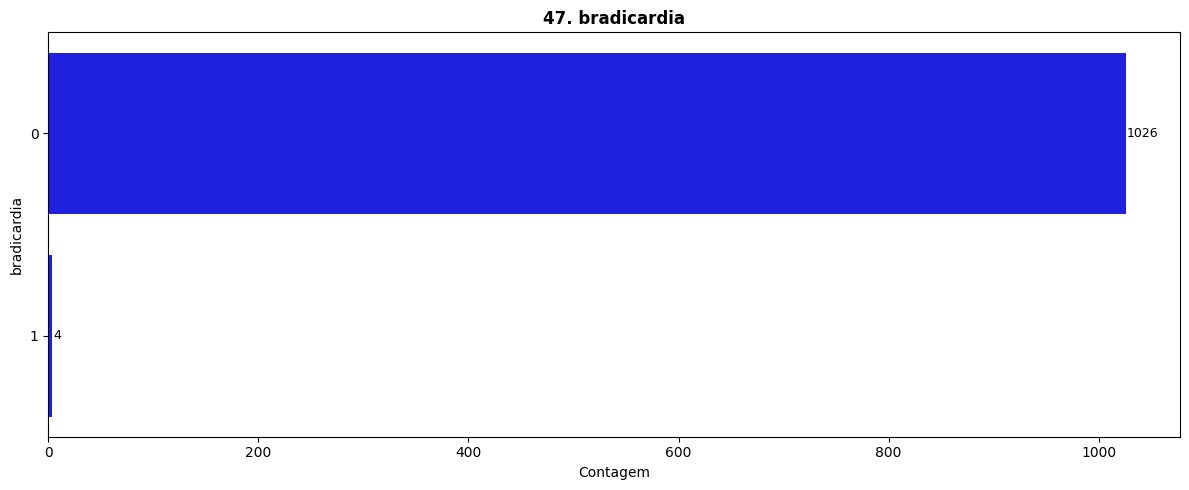

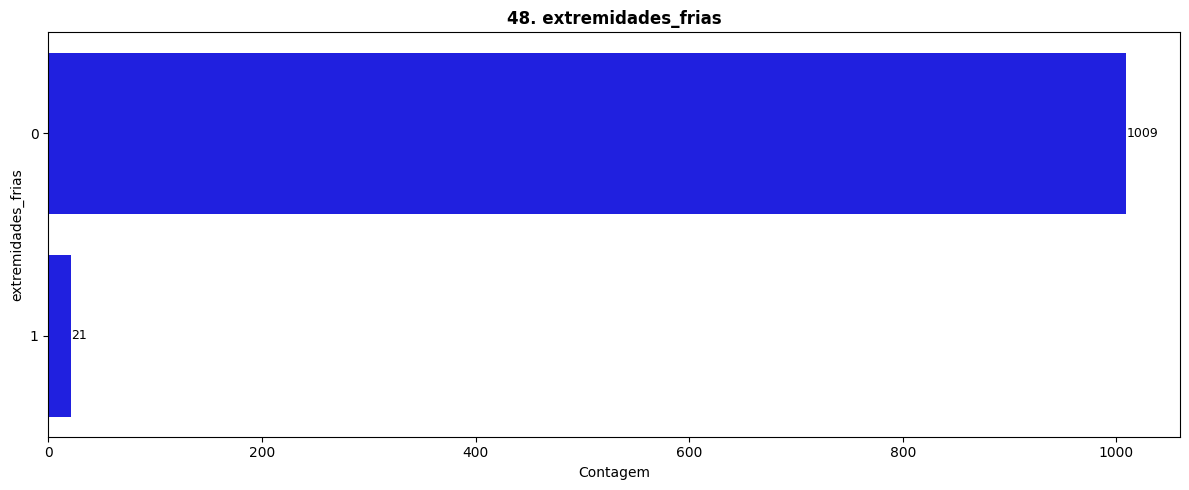

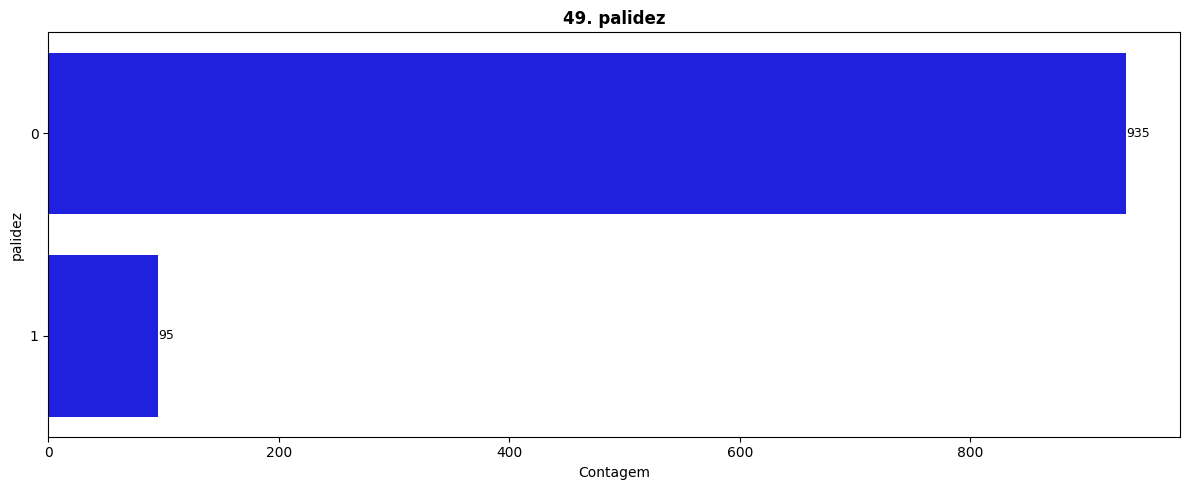

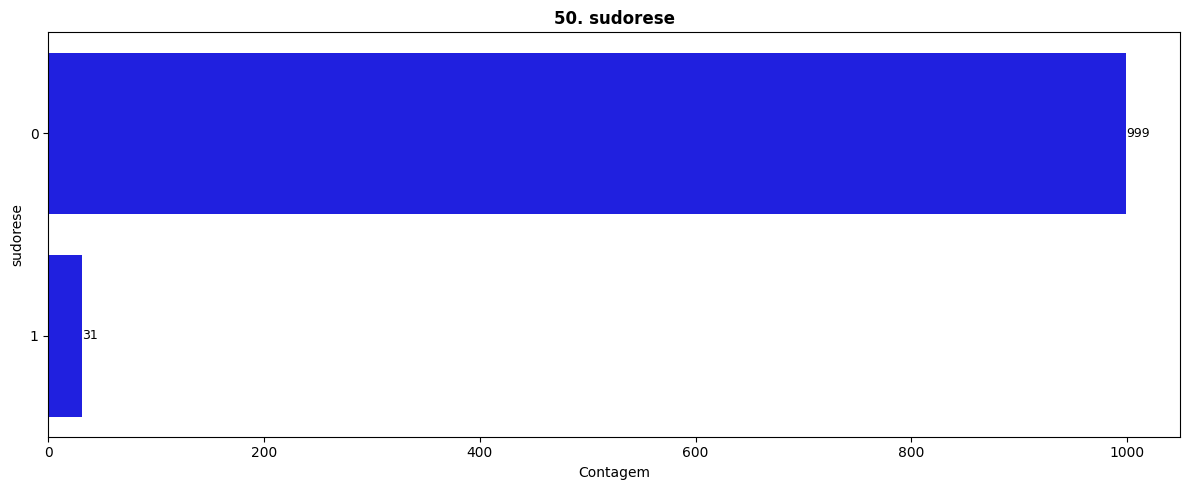

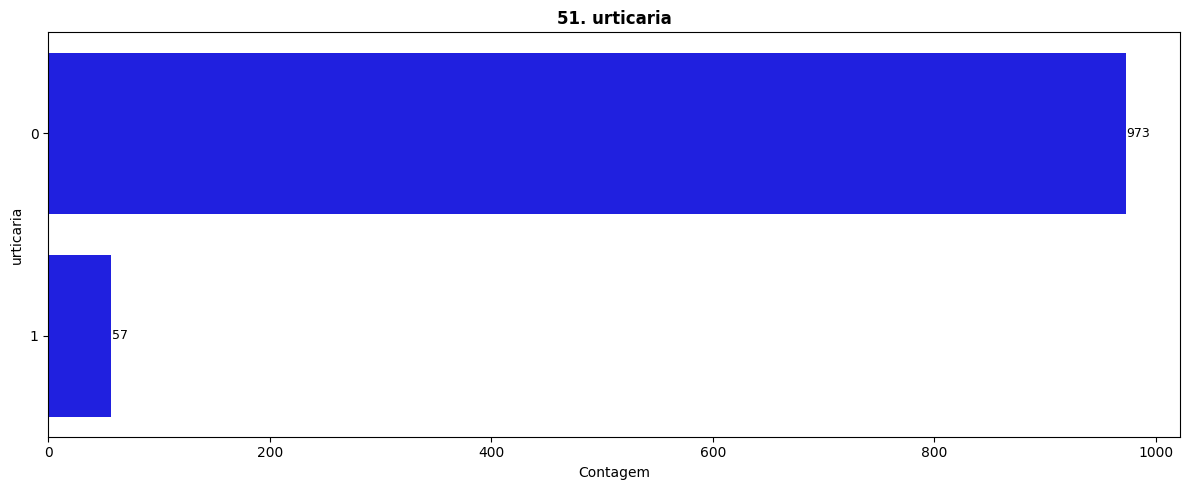

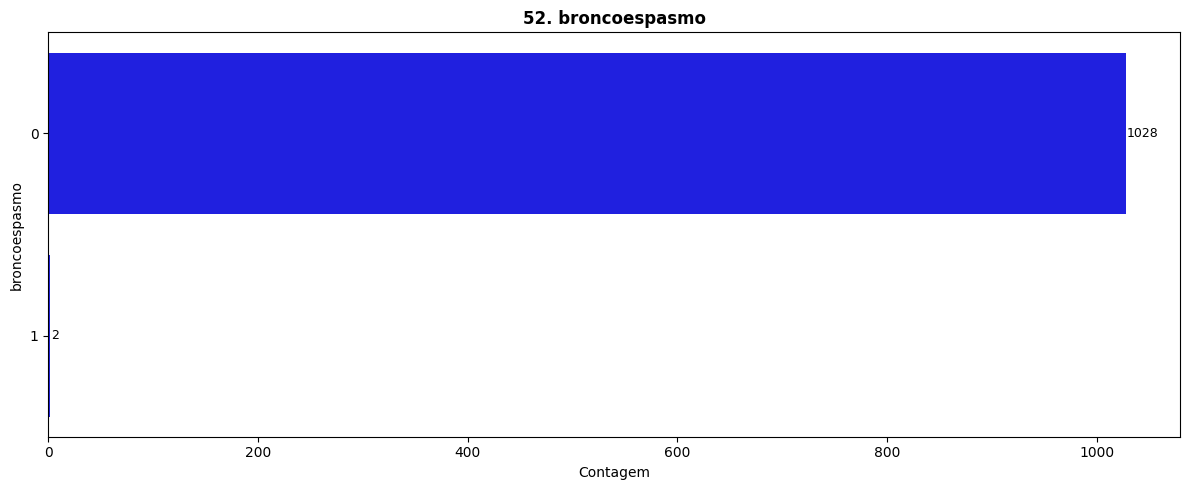

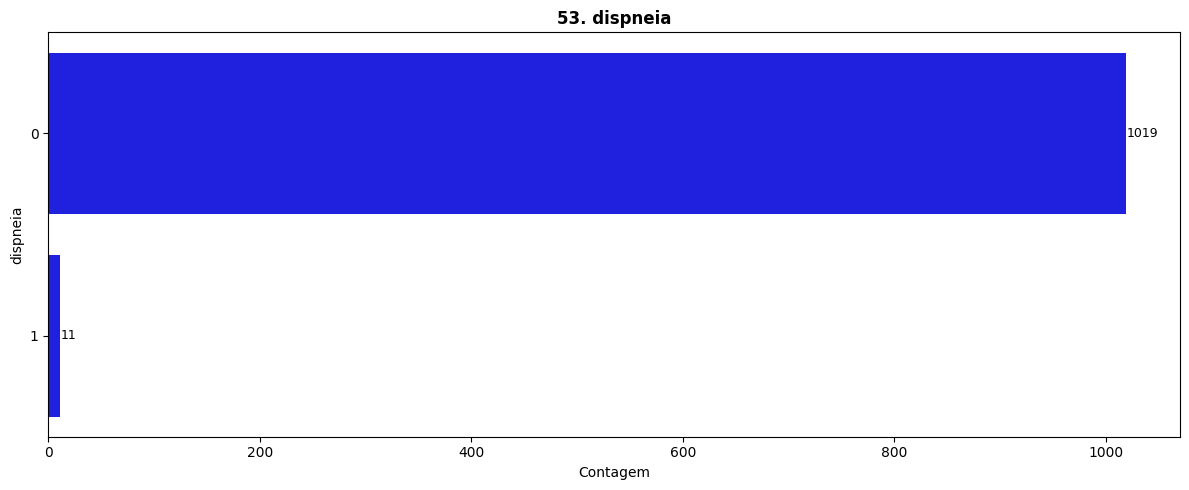

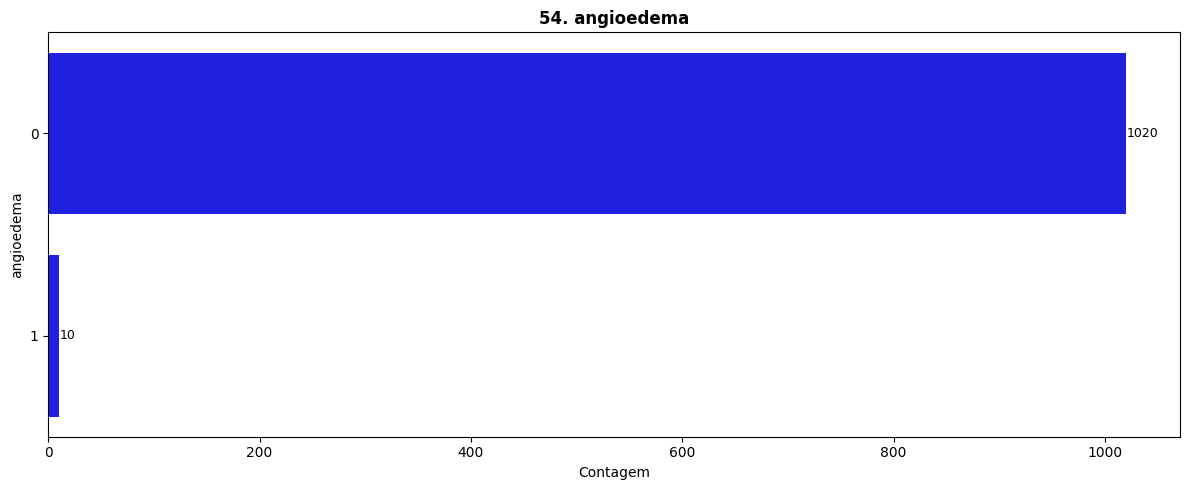

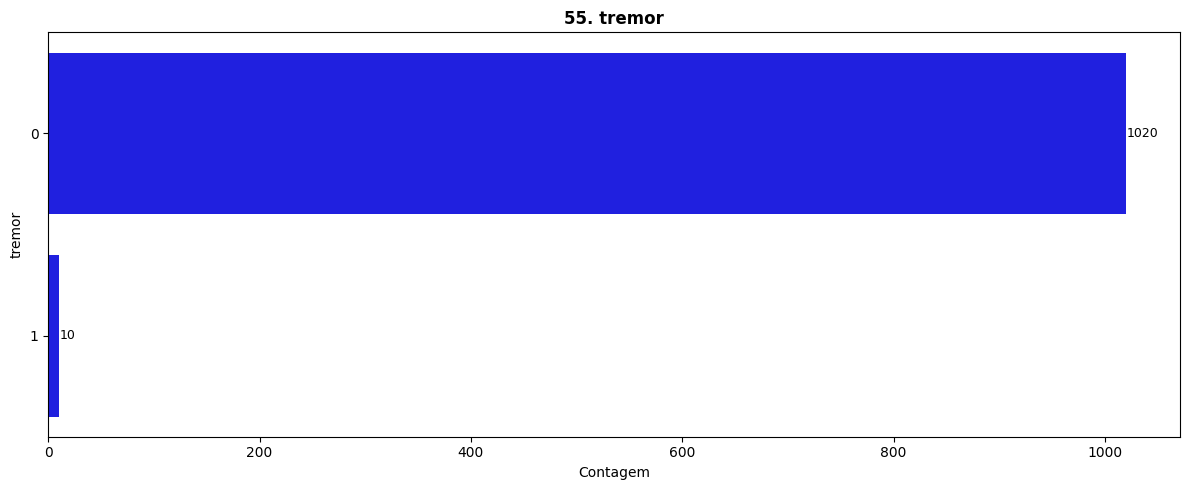

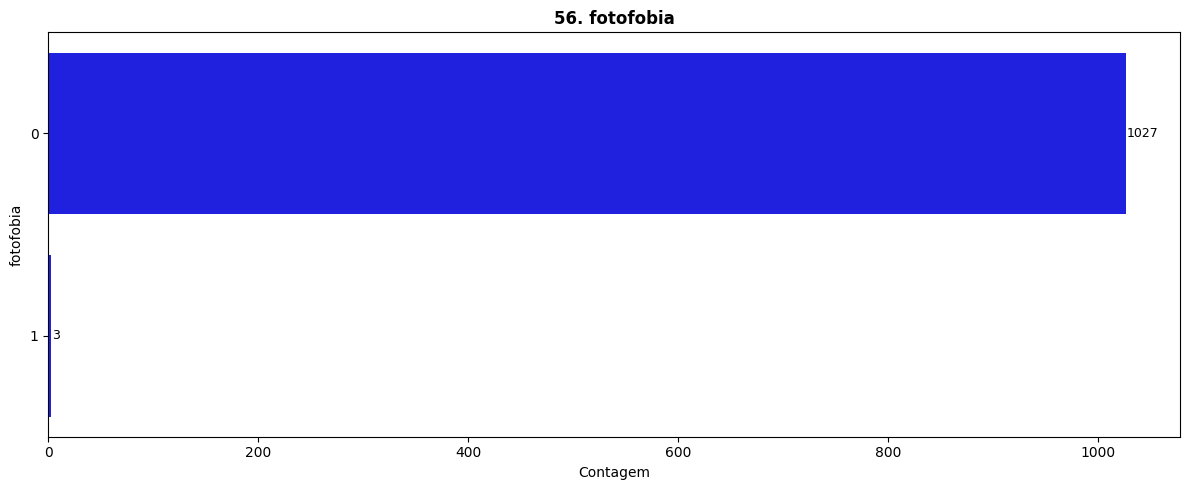

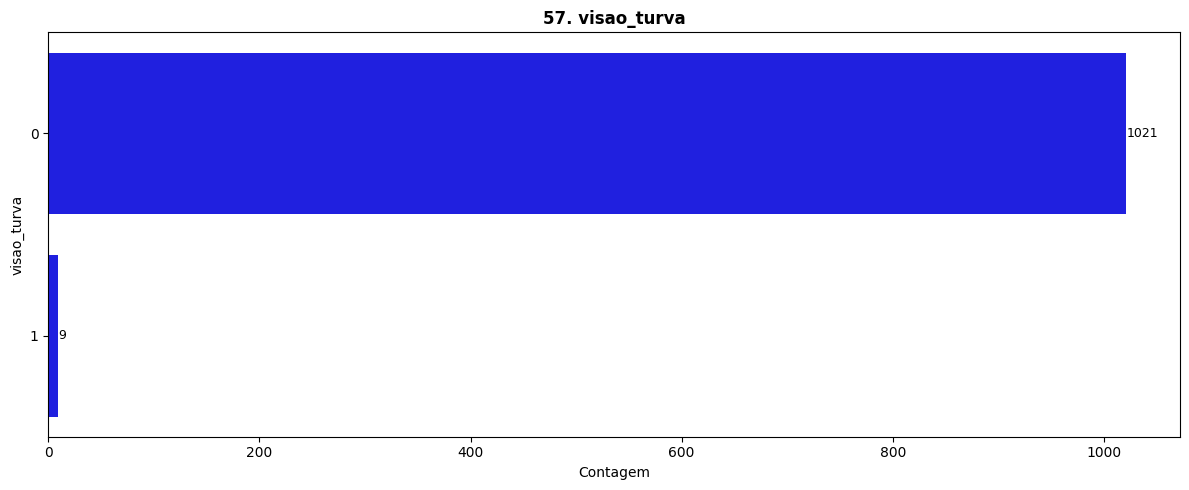

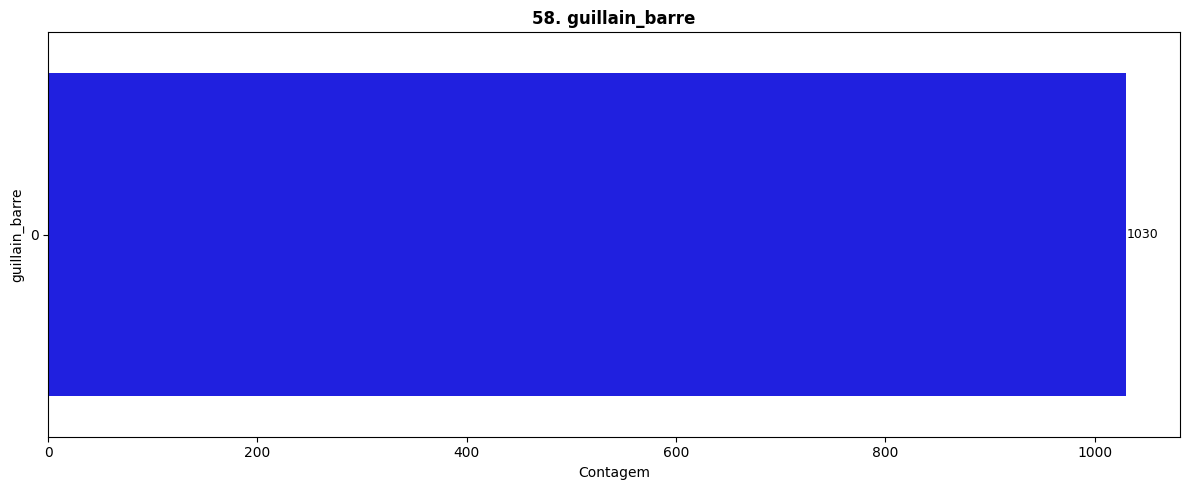

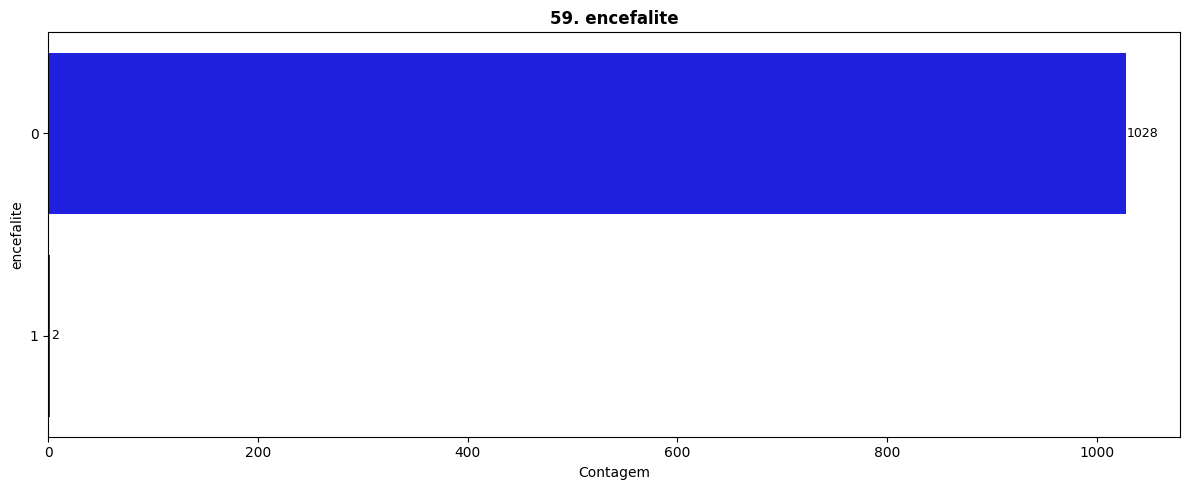

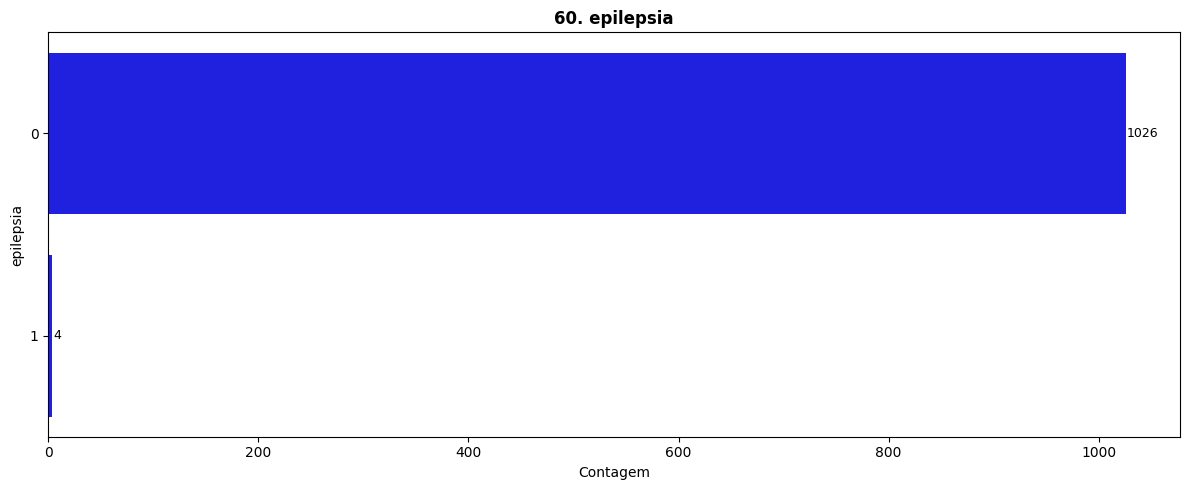

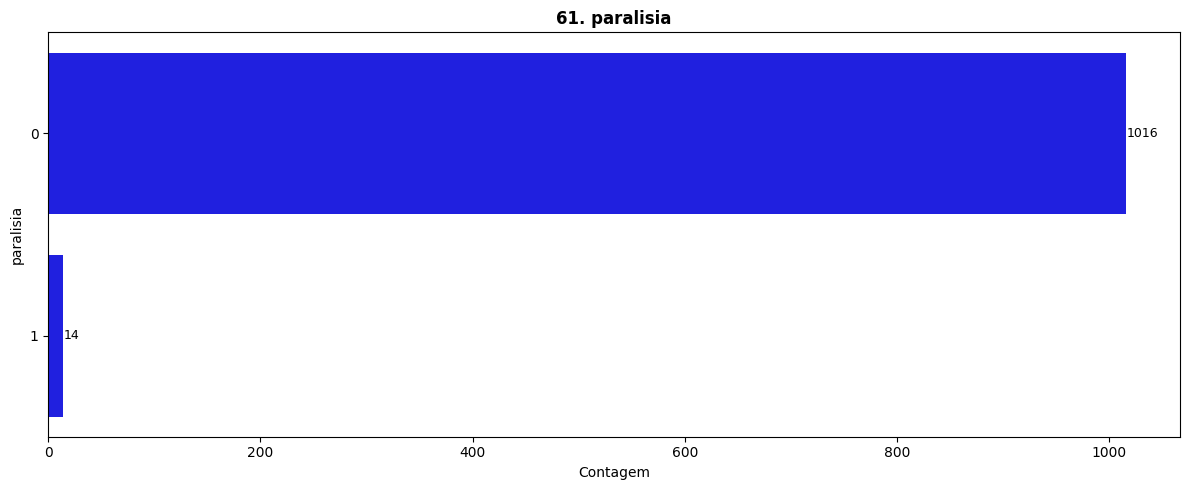

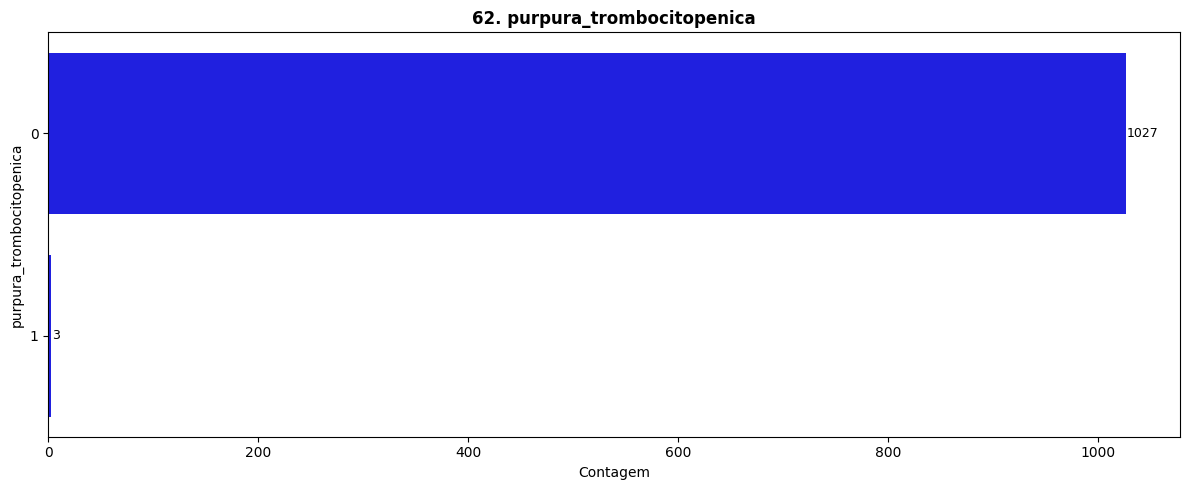

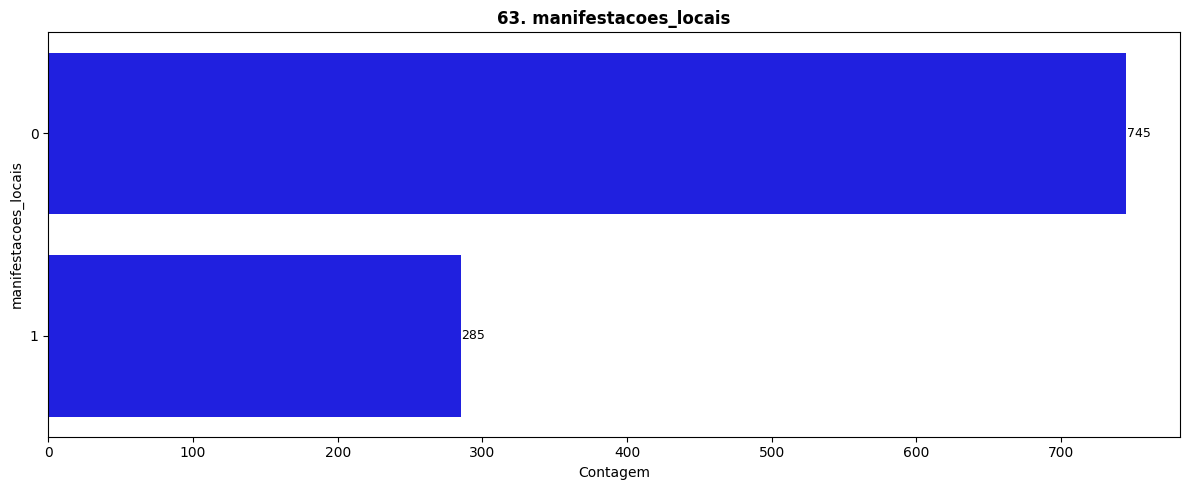

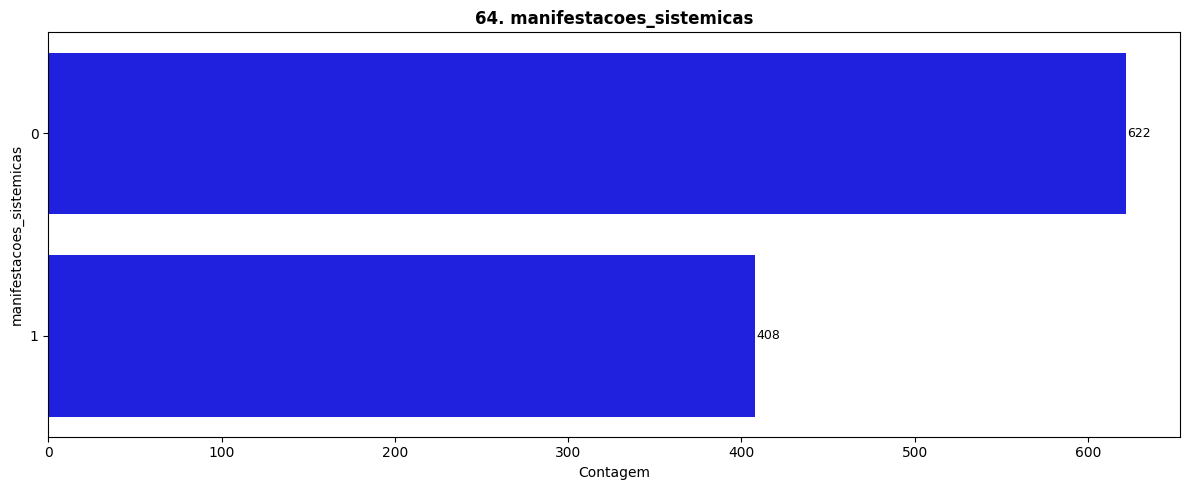

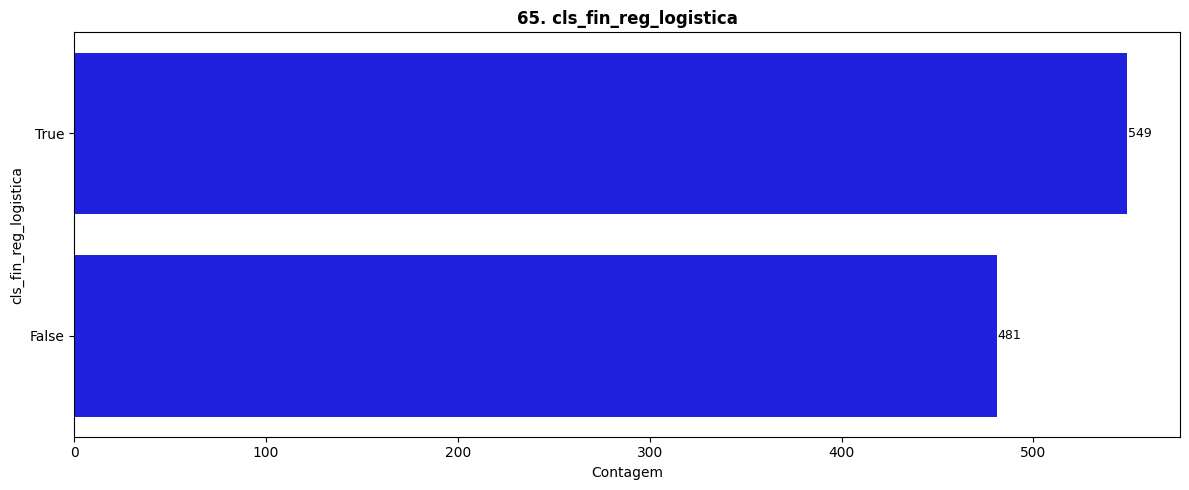

In [4]:
for idx, col in enumerate(dados.columns, start=1):
    contagem = dados[col].value_counts(dropna=False)
    if len(contagem) > 20:
        contagem = contagem.nlargest(20)
        titulo = f"{idx:02d}. {col} (top 20 categorias)"
    else:
        titulo = f"{idx:02d}. {col}"

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=contagem.values, y=contagem.index.astype(str), ax=ax, color='blue')

    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Contagem")
    ax.set_ylabel(col)

    for p in ax.patches:
        ax.annotate(f"{int(p.get_width())}",
                    (p.get_width() + 0.5, p.get_y() + p.get_height() / 2),
                    va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
# **Regressão Logística**
---

## **EANG vs EI**

In [5]:
dados_eang_vs_ei = dados.drop('cls_fin_ajustada', axis=1)

### **Incluindo**

In [6]:
y = dados_eang_vs_ei['cls_fin_reg_logistica'].astype(int)
colunas_teste = [
    'regiao', 
    'idade_anos',
    'sexo',
    'dt_apl_ano',
    'local_aplic_ajustada',
    'via_adm_ajustada',
    'cor',
    'dt_not_ano',
    'pais_nasc',
    'dose_ajustada',
    'gestante',
    'tp_med',
    'manifestacoes_sistemicas',
    'manifestacoes_locais',
    'tp_atd_ajustada'

]


In [7]:
X_reduzido = pd.get_dummies(dados_eang_vs_ei[colunas_teste], drop_first=True).astype(float)
X_reduzido = sm.add_constant(X_reduzido)

try:
    modelo_teste = sm.Logit(y, X_reduzido).fit()
    print(modelo_teste.summary())
except Exception as e:
    print(f"Erro no modelo reduzido: {e}")

Optimization terminated successfully.
         Current function value: 0.125543
         Iterations 27
Erro no modelo reduzido: Singular matrix


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Verifica se o modelo foi criado com sucesso antes de tentar plotar
if 'modelo_teste' in locals():
    
    # 1. Obter as probabilidades previstas pelo modelo
    y_prob = modelo_teste.predict(X_reduzido)

    # 2. Calcular o valor do AUC
    auc_score = roc_auc_score(y, y_prob)

    # 3. Calcular as taxas de Falsos Positivos (FPR) e Verdadeiros Positivos (TPR)
    fpr, tpr, thresholds = roc_curve(y, y_prob)

    # 4. Configurar e plotar o gráfico da Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
    
    # Linha de referência (modelo aleatório que não tem poder de predição, AUC = 0.5)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Base (AUC = 0.5)')
    
    # Formatação do gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # Exibir o gráfico
    plt.show()
else:
    print("O gráfico não pode ser gerado porque o modelo não foi ajustado corretamente.")

O gráfico não pode ser gerado porque o modelo não foi ajustado corretamente.


In [9]:
import numpy as np

X_reduzido = pd.get_dummies(dados[colunas_teste], drop_first=True).astype(float)
X_reduzido = sm.add_constant(X_reduzido)

# ── detectar colunas colineares ──────────────────────────
correlacao = X_reduzido.corr().abs()
colunas_colineares = []

for i in range(len(correlacao.columns)):
    for j in range(i+1, len(correlacao.columns)):
        if correlacao.iloc[i, j] == 1.0:
            col_j = correlacao.columns[j]
            print(f"Correlação perfeita: {correlacao.columns[i]}  ←→  {col_j}")
            if col_j not in colunas_colineares:
                colunas_colineares.append(col_j)

print(f"\nColunas a remover: {colunas_colineares}")

# ── remover colineares e rodar novamente ─────────────────
X_limpo = X_reduzido.drop(columns=colunas_colineares)

# ── verificar também pelo rank da matriz ─────────────────
rank = np.linalg.matrix_rank(X_limpo.values)
print(f"\nColunas: {X_limpo.shape[1]} | Rank: {rank}")
if rank < X_limpo.shape[1]:
    print("⚠️ Ainda há colinearidade — rank menor que número de colunas")

try:
    modelo_teste = sm.Logit(y, X_limpo).fit()
    print(modelo_teste.summary())
except Exception as e:
    print(f"Erro: {e}")

Correlação perfeita: local_aplic_ajustada_não informado  ←→  via_adm_ajustada_vazio

Colunas a remover: ['via_adm_ajustada_vazio']

Colunas: 26 | Rank: 26
Optimization terminated successfully.
         Current function value: 0.125543
         Iterations 27
Erro: Singular matrix


## **EAG vs EANG**

In [10]:
print(dados['cls_fin_ajustada'].value_counts())

cls_fin_ajustada
EANG                   508
EI                     477
EAG                     41
EI - evento adverso      4
Name: count, dtype: int64


In [11]:
# Lista de valores que retornam True e False
targets_true = ['EAG']
targets_false = ['EANG']

dados_eang_vs_eag = dados[dados['cls_fin_ajustada'] != 'Inclassificável']
dados_eang_vs_eag = dados_eang_vs_eag[dados_eang_vs_eag['cls_fin_ajustada'] != 'EI']
dados_eang_vs_eag = dados_eang_vs_eag[dados_eang_vs_eag['cls_fin_ajustada'] != 'EI - evento adverso']

# Cria a nova variável comparando com a lista
dados_eang_vs_eag['cls_fin_reg_logistica_eag_eang'] = dados_eang_vs_eag['cls_fin_ajustada'].isin(targets_true)

# Validação: verificar que temos apenas os valores esperados
print("Valores únicos em 'cls_fin_ajustada' (após filtro):")
print(dados_eang_vs_eag['cls_fin_ajustada'].unique())
print("\nDistribuição da variável de regressão logística:")

Valores únicos em 'cls_fin_ajustada' (após filtro):
<StringArray>
['EANG', 'EAG']
Length: 2, dtype: str

Distribuição da variável de regressão logística:


cls_fin_reg_logistica_eag_eang
False    508
True      41
Name: count, dtype: int64


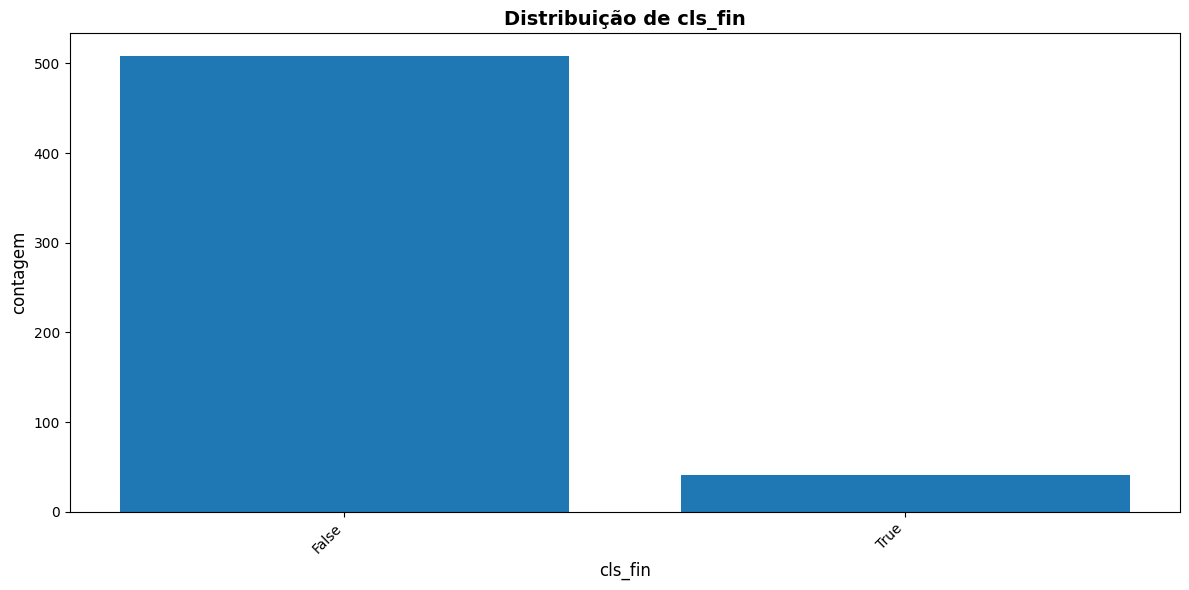

In [12]:
uf_counts = dados_eang_vs_eag['cls_fin_reg_logistica_eag_eang'].value_counts().sort_values(ascending=False)

print(uf_counts)

plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('cls_fin', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de cls_fin', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [13]:
y = dados_eang_vs_eag['cls_fin_reg_logistica_eag_eang'].astype(int)
colunas_teste = [
    'regiao', 
    'idade_anos',
    'sexo',
    'cor'
    'dt_apl_ano',
    'local_aplic_ajustada',
    'dt_not_ano',
    'dose_ajustada',
    'tp_med',
    'manifestacoes_sistemicas',
    'manifestacoes_locais',
    'tp_atd_ajustada'
]


In [14]:
X_reduzido = pd.get_dummies(dados_eang_vs_eag[colunas_teste], drop_first=True).astype(float)
X_reduzido = sm.add_constant(X_reduzido)

try:
    modelo_teste = sm.Logit(y, X_reduzido).fit()
    print(modelo_teste.summary())
except Exception as e:
    print(f"Erro no modelo reduzido: {e}")

Optimization terminated successfully.
         Current function value: 0.167249
         Iterations 10
                                 Logit Regression Results                                 
Dep. Variable:     cls_fin_reg_logistica_eag_eang   No. Observations:                  549
Model:                                      Logit   Df Residuals:                      529
Method:                                       MLE   Df Model:                           19
Date:                            Wed, 06 May 2026   Pseudo R-squ.:                  0.3703
Time:                                    02:38:01   Log-Likelihood:                -91.820
converged:                                   True   LL-Null:                       -145.81
Covariance Type:                        nonrobust   LLR p-value:                 1.883e-14
                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('modelo', LogisticRegression(max_iter=1000, solver='saga'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_reduzido, y, cv=cv, scoring='roc_auc')
print(f"AUC médio: {scores.mean():.3f} ± {scores.std():.3f}")

AUC médio: 0.788 ± 0.092


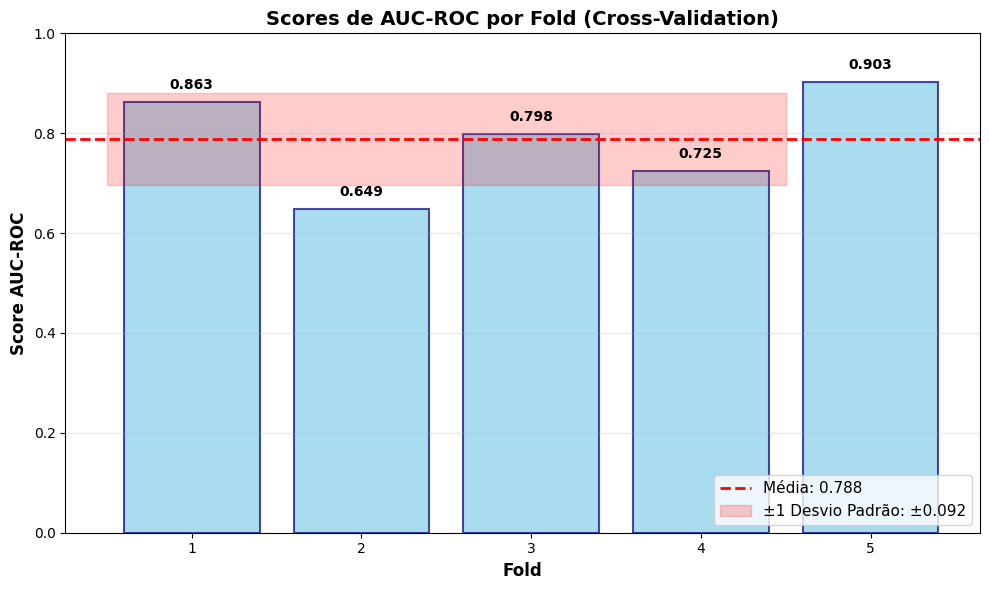

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Criar gráfico dos scores de AUC por fold
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras com os scores de cada fold
folds = range(1, len(scores) + 1)
ax.bar(folds, scores, alpha=0.7, color='skyblue', edgecolor='navy', linewidth=1.5)

# Linha horizontal com a média
ax.axhline(y=scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {scores.mean():.3f}')

# Preenchimento para mostrar o desvio padrão
ax.fill_between(np.arange(0.5, len(scores) + 0.5, 1), 
                scores.mean() - scores.std(), 
                scores.mean() + scores.std(), 
                alpha=0.2, color='red', label=f'±1 Desvio Padrão: ±{scores.std():.3f}')

# Configuração do gráfico
ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score AUC-ROC', fontsize=12, fontweight='bold')
ax.set_title('Scores de AUC-ROC por Fold (Cross-Validation)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.set_xticks(folds)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='lower right')

# Adicionar valores nos topos das barras
for i, (fold, score) in enumerate(zip(folds, scores)):
    ax.text(fold, score + 0.02, f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

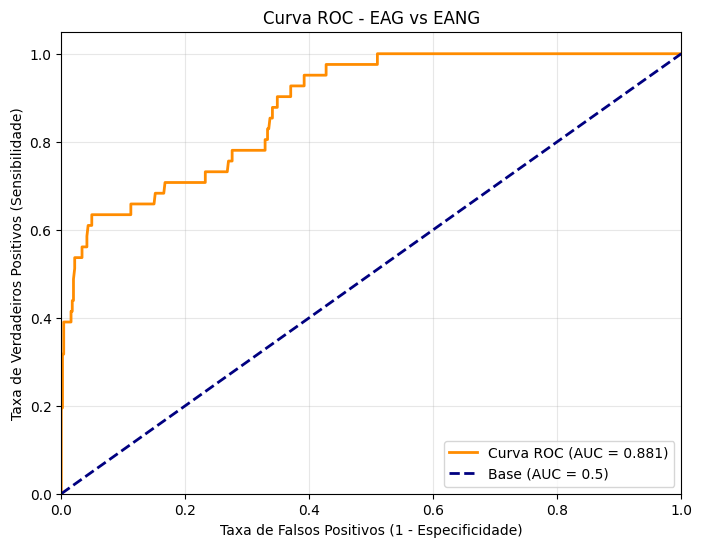

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Verifica se o modelo foi criado com sucesso antes de tentar plotar
if 'modelo_teste' in locals():
    
    # 1. Obter as probabilidades previstas pelo modelo
    y_prob = modelo_teste.predict(X_reduzido)

    # 2. Calcular o valor do AUC
    auc_score = roc_auc_score(y, y_prob)

    # 3. Calcular as taxas de Falsos Positivos (FPR) e Verdadeiros Positivos (TPR)
    fpr, tpr, thresholds = roc_curve(y, y_prob)

    # 4. Configurar e plotar o gráfico da Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
    
    # Linha de referência (modelo aleatório que não tem poder de predição, AUC = 0.5)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Base (AUC = 0.5)')
    
    # Formatação do gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC - EAG vs EANG')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # Exibir o gráfico
    plt.show()
else:
    print("O gráfico não pode ser gerado porque o modelo não foi ajustado corretamente.")